In [1]:
import importlib
import sys
from pathlib import Path

# Add mjosa_code root to path
mjosa_code_root = Path.cwd().parent  # Up to mjosa_code root
sys.path.insert(0, str(mjosa_code_root))

# Import from mjosa_code (NEW structure)
from utils.uhi import georef
from utils.common import config

importlib.reload(georef)  # RELOAD to get updated function!
from utils.uhi.georef import *

print(f"✅ Imports successful! mjosa_code root: {mjosa_code_root}")
print(f"✅ NEW FEATURES LOADED:")
print(f"   - Gaussian smoothing (smoothing_method='gaussian', gaussian_sigma=value)")
print(f"   - L2 normalization (normalization_method='l2')")

✅ Imports successful! mjosa_code root: e:\mjosa_complete\gref4hsi\mjosa_code
✅ NEW FEATURES LOADED:
   - Gaussian smoothing (smoothing_method='gaussian', gaussian_sigma=value)
   - L2 normalization (normalization_method='l2')


## Load UHI Data

In [2]:
# Load transect 057
transect = load_transect(config.TRANSECT_057_OUTPUT)
transect.list_files()

# Select file from transect 057
cube = transect.select_files(["rad_uhi_20241029_115057_5"])
cube.describe()


📋 Files in output (corrected=False):
 1. rad_uhi_20241029_115057_1  | shape=(1333, 968, 210)  | has_georef=True
 2. rad_uhi_20241029_115057_2  | shape=(1946, 968, 210)  | has_georef=True
 3. rad_uhi_20241029_115057_3  | shape=(2227, 968, 210)  | has_georef=True
 4. rad_uhi_20241029_115057_4  | shape=(2463, 968, 210)  | has_georef=True
 5. rad_uhi_20241029_115057_5  | shape=(2462, 968, 210)  | has_georef=True
 6. rad_uhi_20241029_115057_6  | shape=(155, 968, 210)  | has_georef=True
🔄 Rebuilding grids from georef hits for selected files...
   • rad_uhi_20241029_115057_5
  rad_uhi_20241029_115057_5: Using GRIDDED format (T=2462, S=968)
  rad_uhi_20241029_115057_5: Using GRIDDED format (T=2462, S=968)


✅ Combined shapes: X/Y/Z (2462, 968), RGB (2462, 968)
🔄 Loading full hyperspectral cube...
   • Loading rad_uhi_20241029_115057_5...
✅ Loaded full cube: (2462, 968, 210) (T × S × B)

=== Combined_output ===
Tracks × Slits: 2462 × 968
Spectral bands: 210
RGB coverage: R/G/B finite ratios 1.00/1.00/1.00

📊 Spectral configuration:
   Wavelength range: 380.9 - 748.6 nm
   Band spacing: ~1.75 nm
   Spectral resolution (FWHM): ~5.5 nm (manufacturer spec)

⏱️  Acquisition timing:
   Frame rate: ~20.0 Hz (50.1 ms/frame)

📐 Optical configuration:
   Field of View: 50.6° (±25.3°)

📋 File boundaries:
  rad_uhi_20241029_115057_5: tracks 0–2461 (2462)
✅ Loaded full cube: (2462, 968, 210) (T × S × B)

=== Combined_output ===
Tracks × Slits: 2462 × 968
Spectral bands: 210
RGB coverage: R/G/B finite ratios 1.00/1.00/1.00

📊 Spectral configuration:
   Wavelength range: 380.9 - 748.6 nm
   Band spacing: ~1.75 nm
   Spectral resolution (FWHM): ~5.5 nm (manufacturer spec)

⏱️  Acquisition timing:
   Frame

In [3]:
# Step 1: Apply illumination correction
cube.apply_illumination_correction_v3()

🔄 Using V3 algorithm (rolling window only, strategy=memory)
✅ Illumination correction already exists (window=500, strength=1.0)
   Loading from disk...
📂 Loading saved illumination correction from 1 files...
   rad_uhi_20241029_115057_5: window=500, strength=1.0
✅ Loaded illumination correction from disk
   rad_uhi_20241029_115057_5: window=500, strength=1.0
✅ Loaded illumination correction from disk


array([[[2.2304249e+00, 1.6764377e+00, 0.0000000e+00, ...,
         0.0000000e+00, 7.0077596e+00, 0.0000000e+00],
        [7.4757171e+00, 8.5974735e-01, 0.0000000e+00, ...,
         0.0000000e+00, 3.0958059e+00, 0.0000000e+00],
        [1.8294926e+00, 2.3438740e+00, 0.0000000e+00, ...,
         0.0000000e+00, 7.1090145e+00, 0.0000000e+00],
        ...,
        [1.7213115e+00, 1.4317783e+00, 0.0000000e+00, ...,
         1.0000000e+00, 2.3279436e-02, 3.7040919e-01],
        [5.8812752e+00, 2.0123754e+00, 0.0000000e+00, ...,
         0.0000000e+00, 1.4956644e+00, 0.0000000e+00],
        [2.3867478e+00, 1.0000000e+00, 0.0000000e+00, ...,
         0.0000000e+00, 1.5736811e+01, 4.5105180e-01]],

       [[2.2304249e+00, 7.7452070e-01, 3.9940205e+00, ...,
         0.0000000e+00, 0.0000000e+00, 9.6023534e-05],
        [1.7471981e+00, 0.0000000e+00, 1.2654871e+00, ...,
         0.0000000e+00, 8.5029960e-01, 6.3767982e-01],
        [1.9216584e+00, 0.0000000e+00, 3.0771544e+00, ...,
         0.000

In [4]:
# Step 2: Apply alignment adjustment
cube.adjust_uhi_alignment(dx=-0.05, dy=-3.0)

✅ UHI alignment adjusted:
   dx (East):  -0.050 m
   dy (North): -3.000 m

💡 This will be applied in plot_georef() with coordinate_system='NED'


In [5]:
cube.apply_wavelength_filter(wavelength_range=(490, 700))

🔪 WAVELENGTH FILTERING
📊 Original wavelengths: 210
🎯 Target range: 490-700 nm
✂️  Filtered wavelengths: 119
📉 Range: 490.2 - 699.4 nm

✅ Datacube shape after filtering: (2462, 968, 119)
   Memory: 1.06 GB

✅ Datacube shape after filtering: (2462, 968, 119)
   Memory: 1.06 GB


array([[[0.98425937, 0.93107796, 1.1241757 , ..., 1.0840195 ,
         1.1130555 , 1.2421854 ],
        [1.1061107 , 1.1017638 , 0.9724048 , ..., 1.1835853 ,
         1.0330081 , 0.977461  ],
        [0.85680646, 1.1831337 , 0.93671906, ..., 0.93257195,
         1.0799737 , 1.1921229 ],
        ...,
        [0.9657652 , 1.1174209 , 0.7726173 , ..., 1.4343753 ,
         0.6485653 , 1.0226964 ],
        [0.9529329 , 0.9944295 , 0.92065525, ..., 1.447604  ,
         1.0292426 , 1.5021763 ],
        [0.7290514 , 0.94181645, 0.88388896, ..., 0.96531993,
         0.97378635, 1.2125148 ]],

       [[0.8691471 , 1.0059932 , 1.0689864 , ..., 1.1050243 ,
         1.0835627 , 1.388623  ],
        [1.0374508 , 0.9113789 , 1.151117  , ..., 0.9567099 ,
         1.155609  , 1.1972164 ],
        [0.9745434 , 0.9039299 , 1.117137  , ..., 0.9957858 ,
         1.0188173 , 1.016952  ],
        ...,
        [1.091293  , 0.8879163 , 1.2322206 , ..., 0.97444856,
         1.1203544 , 1.6939743 ],
        [1.2

🔧 DEBUG: plot_georef called with use_wavelength_colormap=False, wavelength_colormap_target=None
💡 Interactive mode: Click on the plot to display coordinates
💡 Interactive mode: Click on the plot to display coordinates


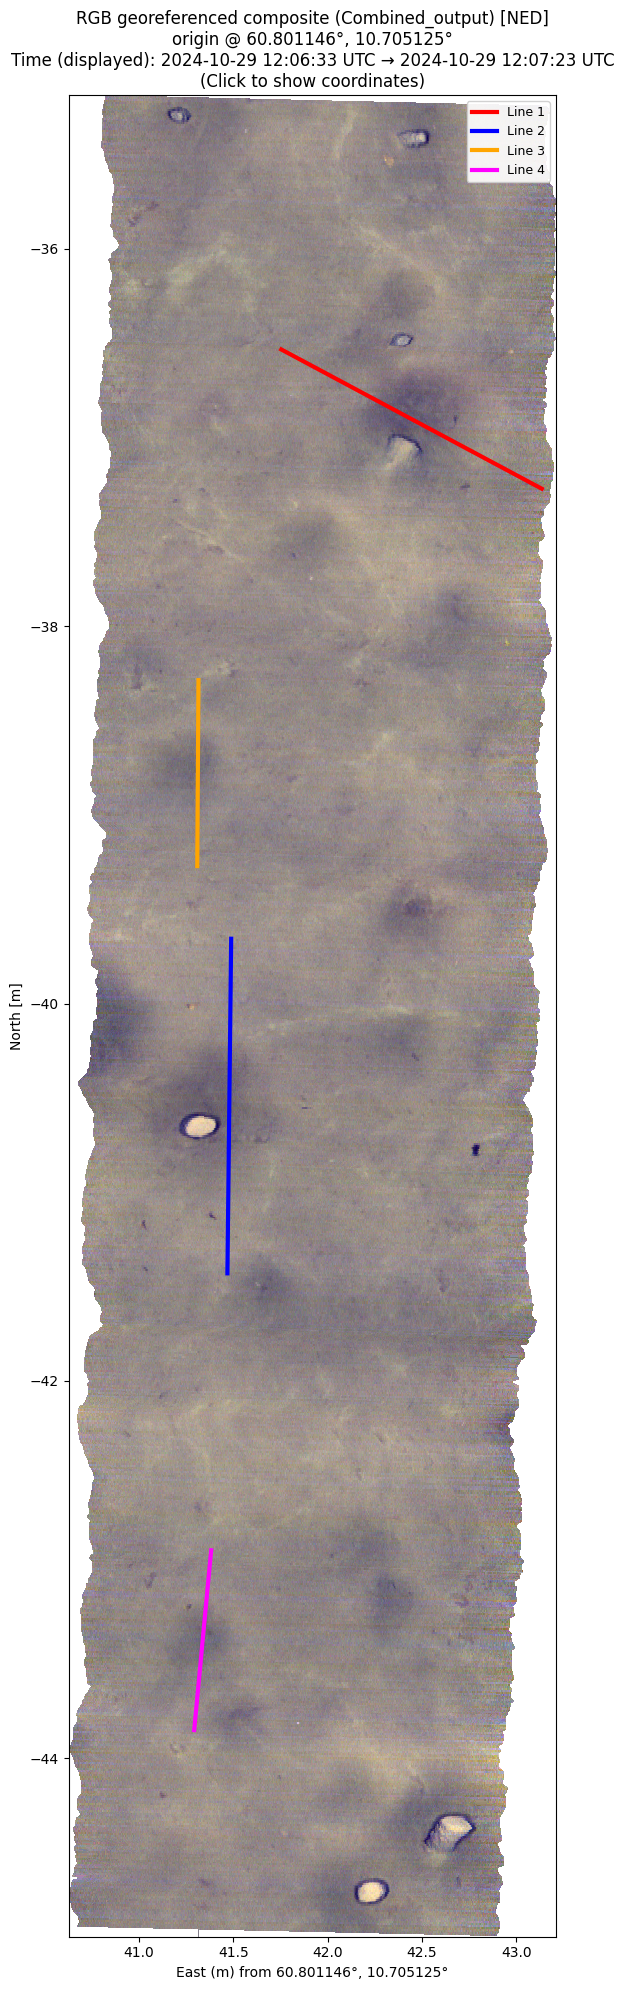

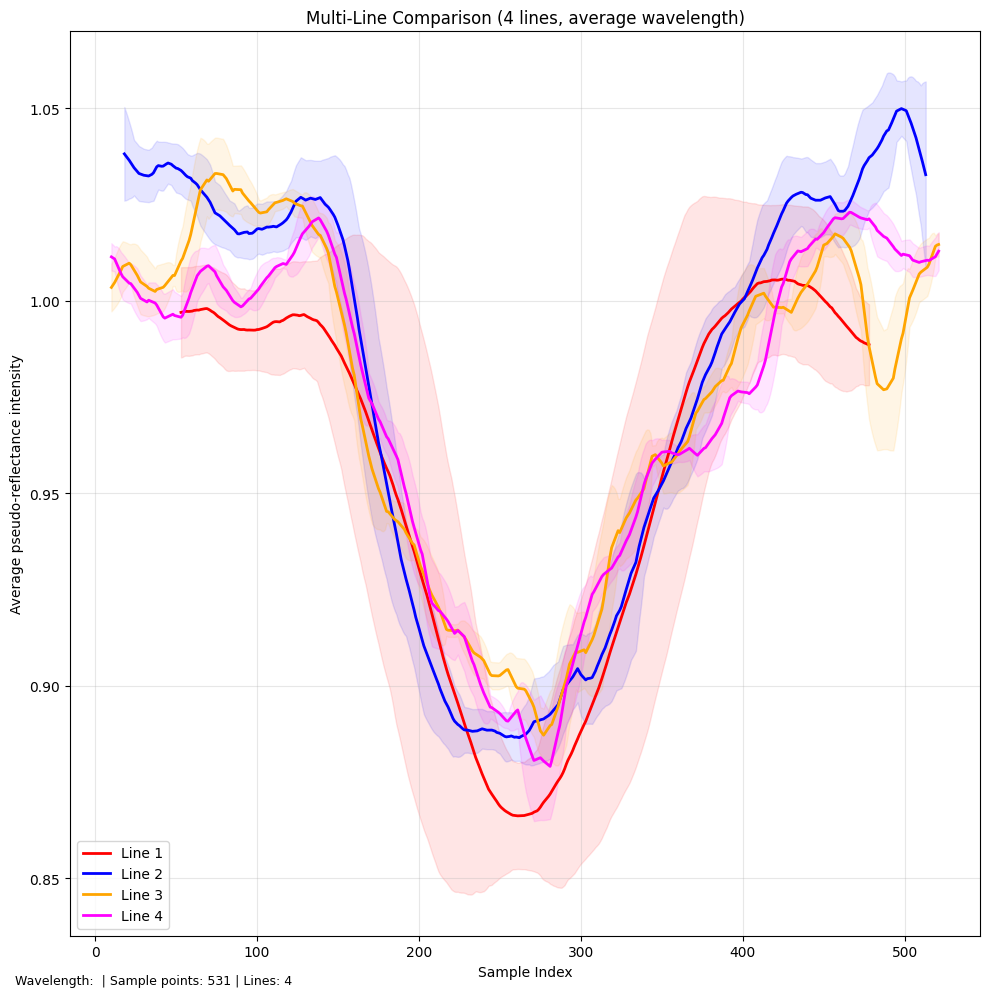

{'wavelength': '',
 'wavelength_method': 'average',
 'smoothing_window': 1,
 'number_of_lines': 4,
 'sample_points': 531,
 'normalized': False,
 'normalization_method': None,
 'lines': [{'line_index': 1,
   'start_point': (410, 710),
   'end_point': (940, 780),
   'sample_indices': array([ 53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,  65,
           66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,  78,
           79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,  91,
           92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103, 104,
          105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117,
          118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130,
          131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143,
          144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156,
          157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169,
          170, 171, 172, 173, 174, 175, 176, 

In [6]:
# Define analysis lines - ADJUSTED for track range (576-1566)
# Place lines within visible data range
line1 = [(410, 710), (940, 780)]
line2 = [(340, 1030), (340, 1210)]
line3 = [(250, 890), (250, 990)]
line4 = [(300, 1358), (300, 1458)]

lines = [line1, line2, line3, line4]
colors = ["red", "blue", "orange", "magenta"]
labels = ["Line 1", "Line 2", "Line 3", "Line 4"]

# Plot RGB georef - EXACT wavelengths: 677nm (R), 610nm (G), 490nm (B)
# plot_georef will find the CLOSEST available wavelength to these targets
cube.plot_georef(
    perimeter_line=lines,
    line_colors=colors,
    line_width=3,
    line_labels=labels,
    use_corrected=True,
    coordinate_system="NED",
    track_start=config.UHI_TRACK_RANGE[0],
    track_end=config.UHI_TRACK_RANGE[1],
    figsize=(50, 20),
    apply_alignment_shift=True,
)

# Intensity profiles for specific wavelength ranges (like dev10)
cube.plot_line_intensity_profile(
    perimeter_line=lines,
    use_average=True,
    moving_average_percent=20,
    show_markers=False,
    line_labels=labels,
    line_colors=colors,
    use_corrected=True,
    wavelength_range="all",  # Red bands (640-680nm) - change to 'green', 'blue', or (490,700)
    figsize=(10, 10),
    use_sparse_sampling=False,
)

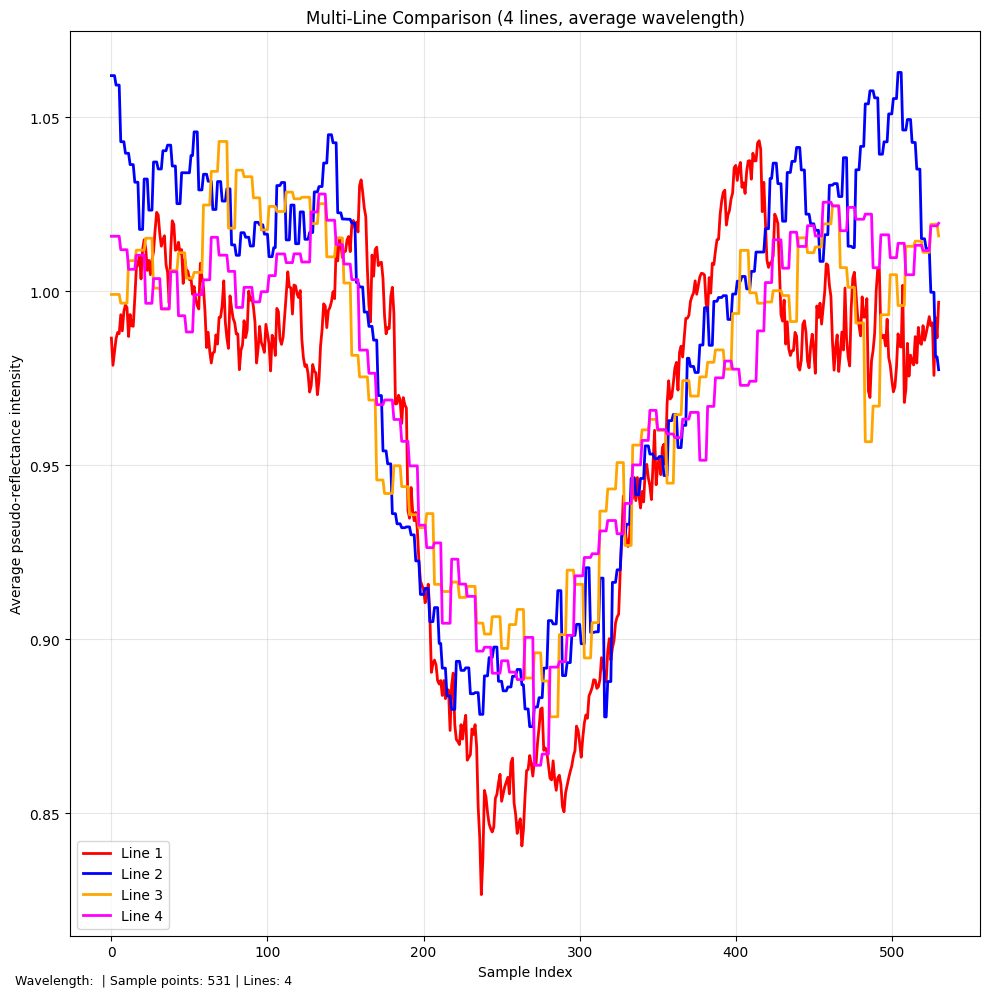

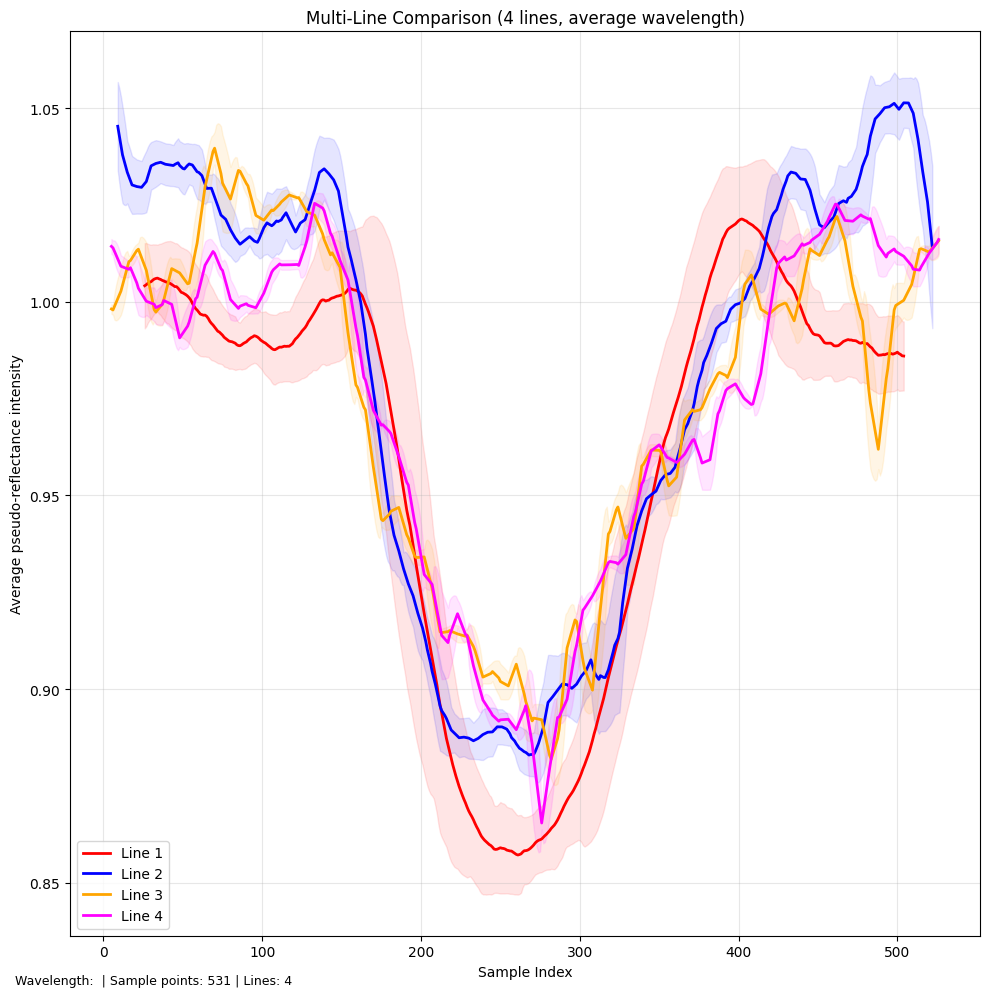

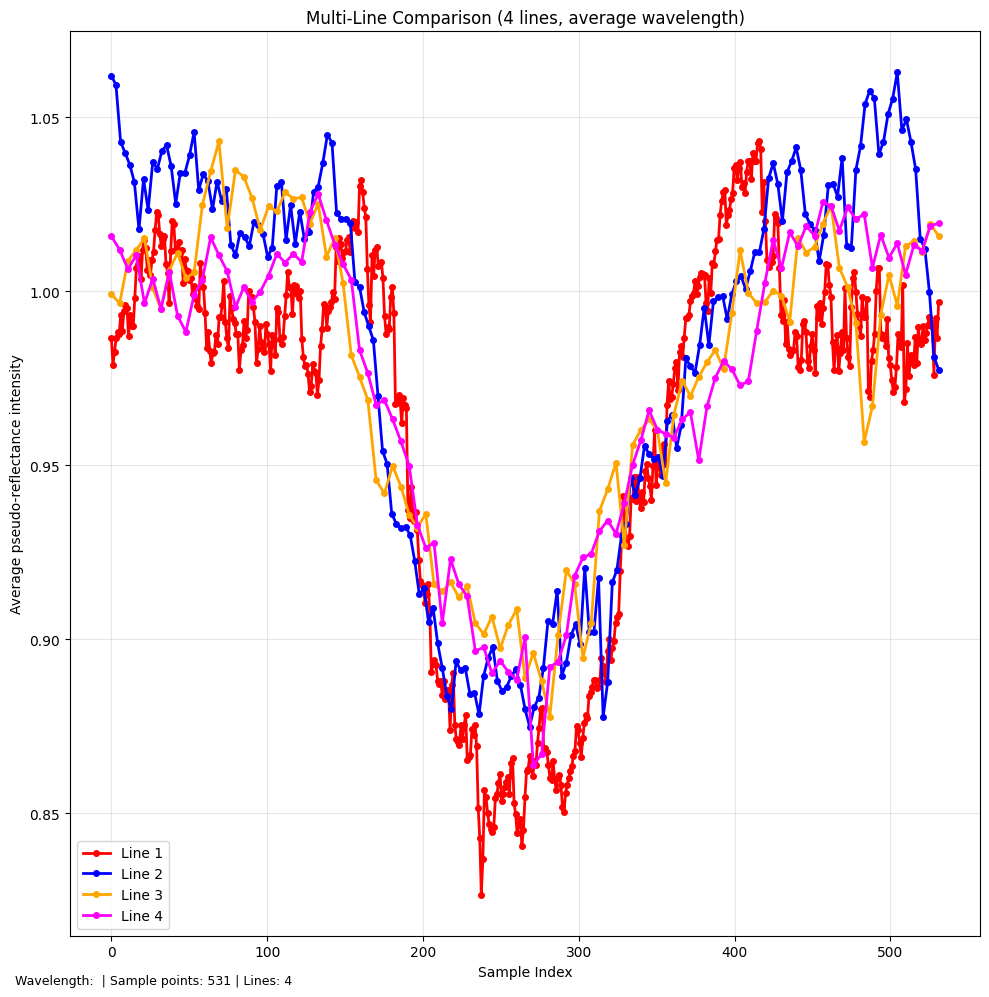

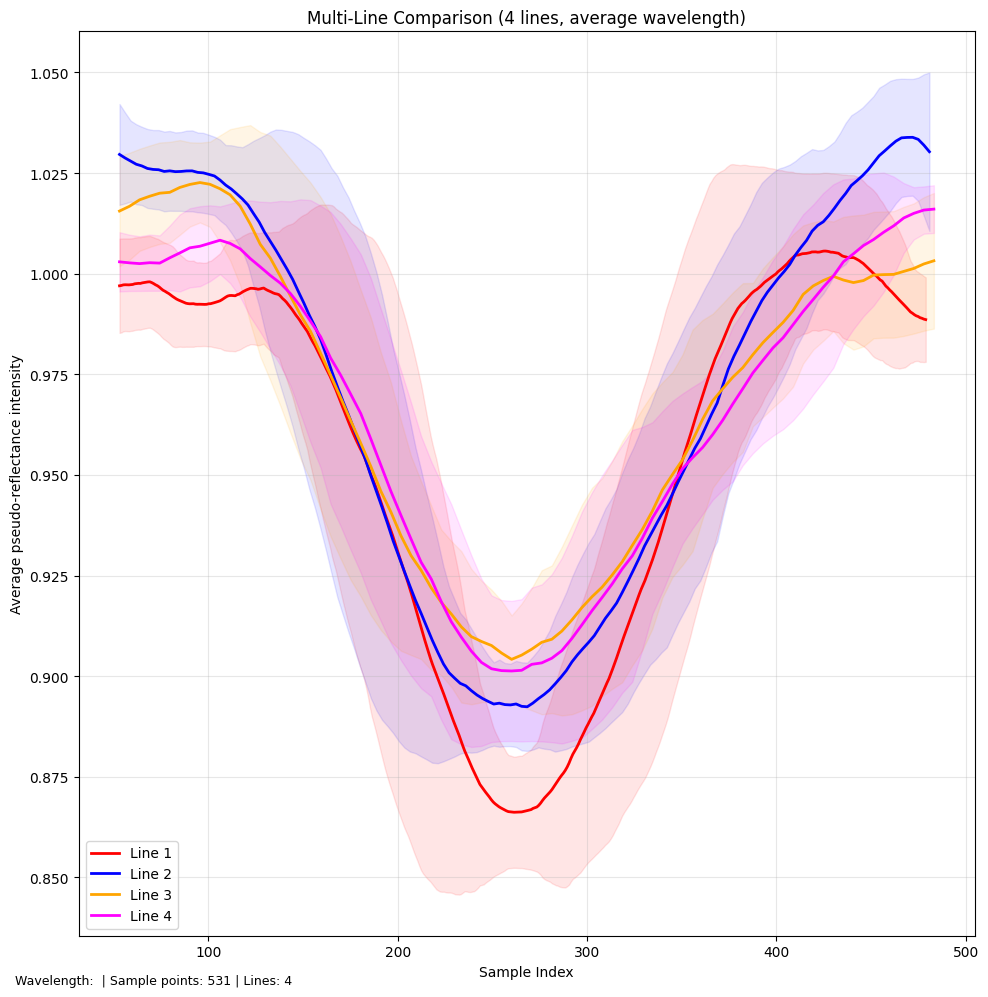

{'wavelength': '',
 'wavelength_method': 'average',
 'smoothing_window': 1,
 'number_of_lines': 4,
 'sample_points': 531,
 'normalized': False,
 'normalization_method': None,
 'lines': [{'line_index': 1,
   'start_point': (410, 710),
   'end_point': (940, 780),
   'sample_indices': array([ 53.1       ,  54.10188679,  55.10377358,  56.10566038,
           57.10754717,  58.10943396,  59.11132075,  60.11320755,
           61.11509434,  62.11698113,  63.11886792,  64.12075472,
           65.12264151,  66.1245283 ,  67.12641509,  68.12830189,
           69.13018868,  70.13207547,  71.13396226,  72.13584906,
           73.13773585,  74.13962264,  75.14150943,  76.14339623,
           77.14528302,  78.14716981,  79.1490566 ,  80.1509434 ,
           81.15283019,  82.15471698,  83.15660377,  84.15849057,
           85.16037736,  86.16226415,  87.16415094,  88.16603774,
           89.16792453,  90.16981132,  91.17169811,  92.17358491,
           93.1754717 ,  94.17735849,  95.17924528,  96.1811

In [17]:
# Intensity profiles for specific wavelength ranges (like dev10)
cube.plot_line_intensity_profile(
    perimeter_line=lines,
    use_average=True,
    moving_average_percent=0,
    show_markers=False,
    line_labels=labels,
    line_colors=colors,
    use_corrected=True,
    wavelength_range="all",  # Red bands (640-680nm) - change to 'green', 'blue', or (490,700)
    figsize=(10, 10),
    use_sparse_sampling=False,
)
cube.plot_line_intensity_profile(
    perimeter_line=lines,
    use_average=True,
    moving_average_percent=10,
    show_markers=False,
    line_labels=labels,
    line_colors=colors,
    use_corrected=True,
    wavelength_range="all",  # Red bands (640-680nm) - change to 'green', 'blue', or (490,700)
    figsize=(10, 10),
    use_sparse_sampling=False,
)
# Intensity profiles for specific wavelength ranges (like dev10)
cube.plot_line_intensity_profile(
    perimeter_line=lines,
    use_average=True,
    moving_average_percent=0,
    show_markers=False,
    line_labels=labels,
    line_colors=colors,
    use_corrected=True,
    wavelength_range="all",  # Red bands (640-680nm) - change to 'green', 'blue', or (490,700)
    figsize=(10, 10),
    use_sparse_sampling=True,
)
cube.plot_line_intensity_profile(
    perimeter_line=lines,
    use_average=True,
    moving_average_percent=20,
    show_markers=False,
    line_labels=labels,
    line_colors=colors,
    use_corrected=True,
    wavelength_range="all",  # Red bands (640-680nm) - change to 'green', 'blue', or (490,700)
    figsize=(10, 10),
    use_sparse_sampling=True,
    sparse_show_markers=False,
)

📊 Auto-calculated moving average window: 106 samples (20% of 531 samples)


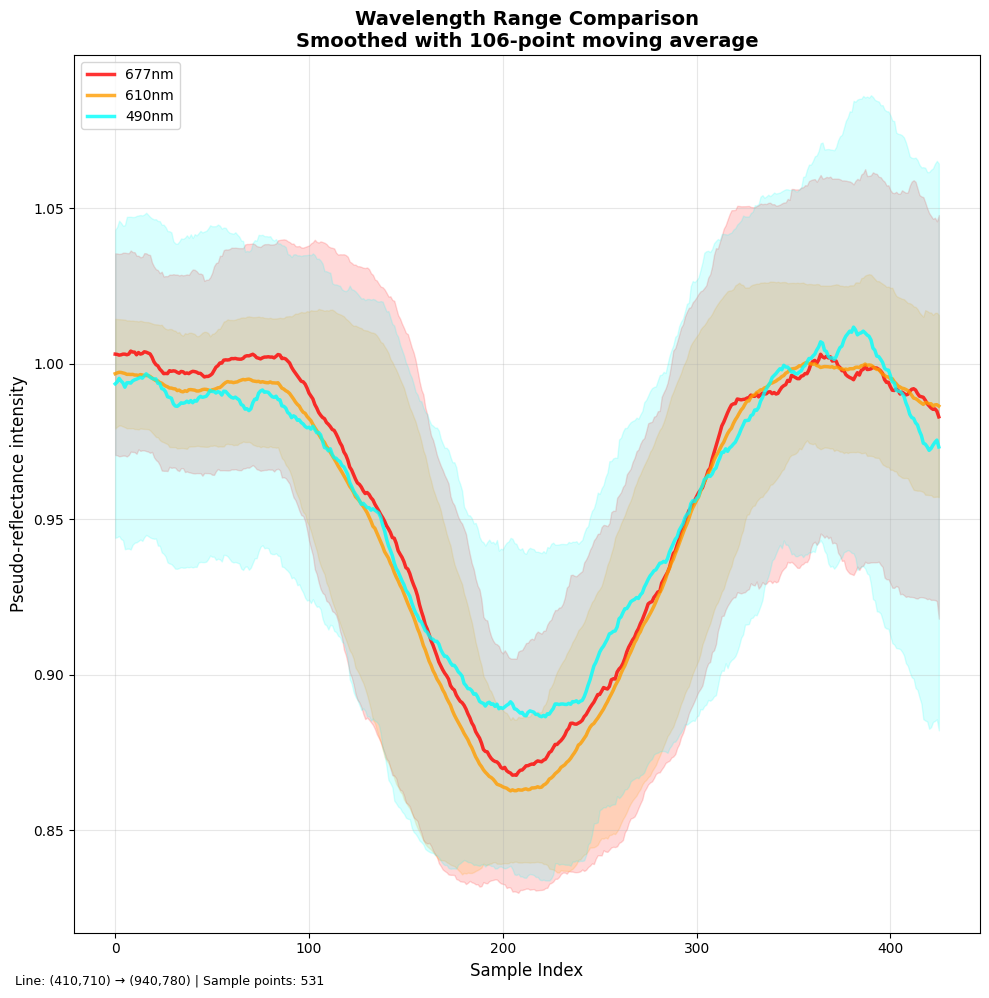

In [8]:
# Wavelength comparison with EXACT wavelengths and ACTUAL PHYSICAL COLORS
# Using the plot_wavelength_comparison function with single wavelength integers
cube.plot_wavelength_comparison(
    line=lines[0],  # Pick which line (0, 1, 2, or 3)
    wavelength_ranges=[
        677,  # Deep red (finds closest: 677.6nm) -> physical red color
        610,  # Orange (finds closest: 609.5nm) -> physical orange color
        490,  # Cyan (finds closest: 490.2nm) -> physical cyan color
    ],
    moving_average_percent=20,
    use_corrected=True,
    figsize=(10, 10),
)

# below i started testing different smoothing

---

---

---

---

---

---

---

---

---

---

---

---

---

---

---

---

## Test New Features: Gaussian Smoothing & L2 Normalization

**⚠️ IMPORTANT: Restart kernel and re-run cells 1-6 before running tests below!**

Testing the new parameters:
- `smoothing_method="gaussian"` with `gaussian_sigma`
- `normalization_method="l2"` for L2 normalization

New features added to both `plot_line_intensity_profile` and `plot_wavelength_comparison`!

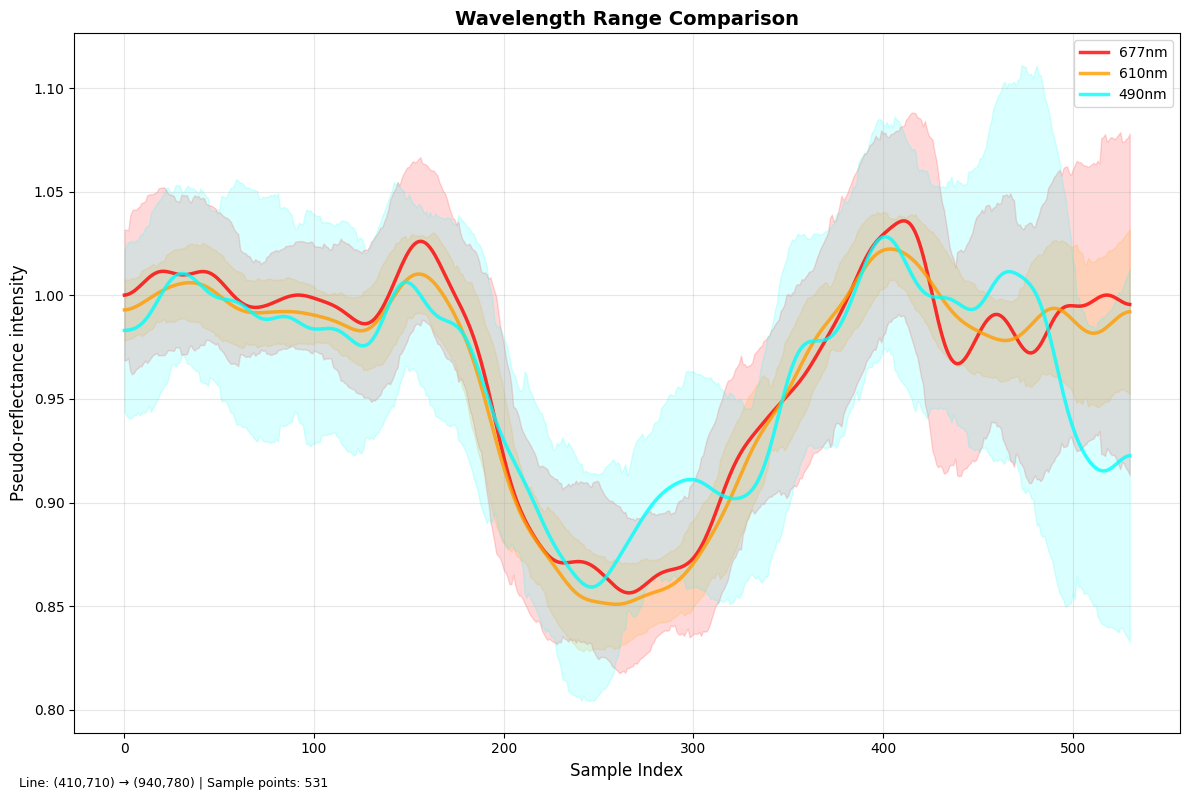


✅ Test 1 complete: Gaussian smoothing with sigma=2.0


In [9]:
# Test 1: Gaussian smoothing with different sigma values
cube.plot_wavelength_comparison(
    line=lines[0],
    wavelength_ranges=[677, 610, 490],
    smoothing_method="gaussian",  # NEW: Gaussian smoothing
    gaussian_sigma=10.0,  # NEW: Sigma parameter
    use_corrected=True,
)
print("\n✅ Test 1 complete: Gaussian smoothing with sigma=2.0")

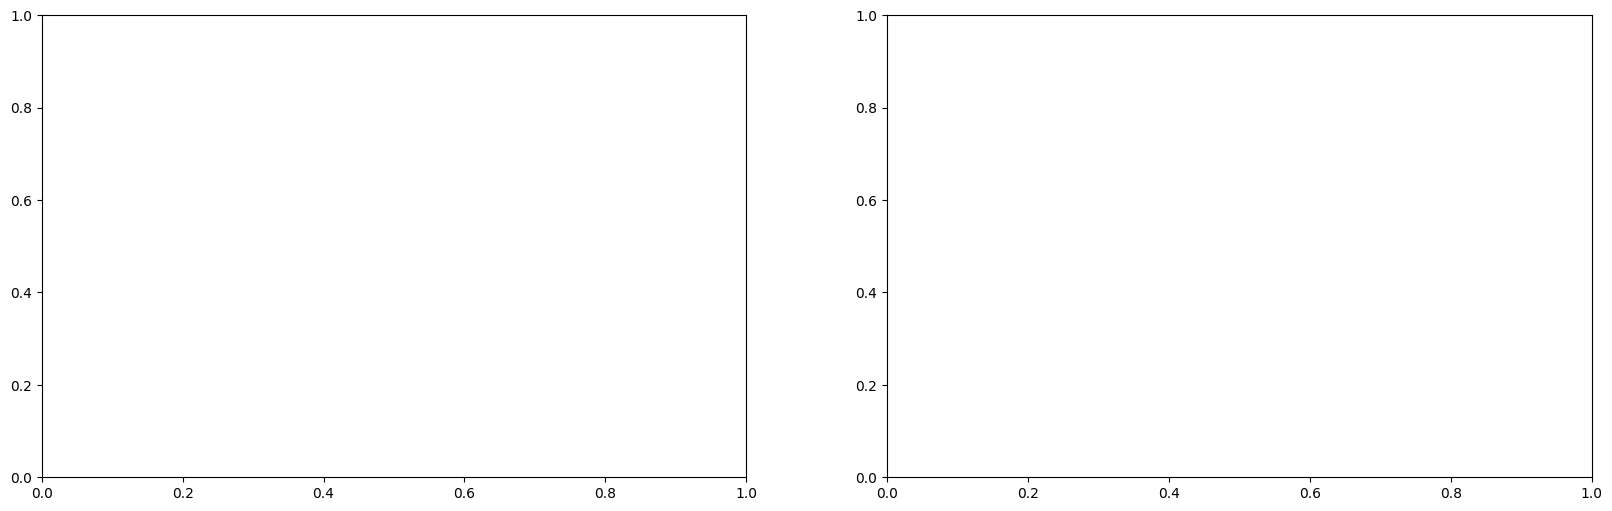

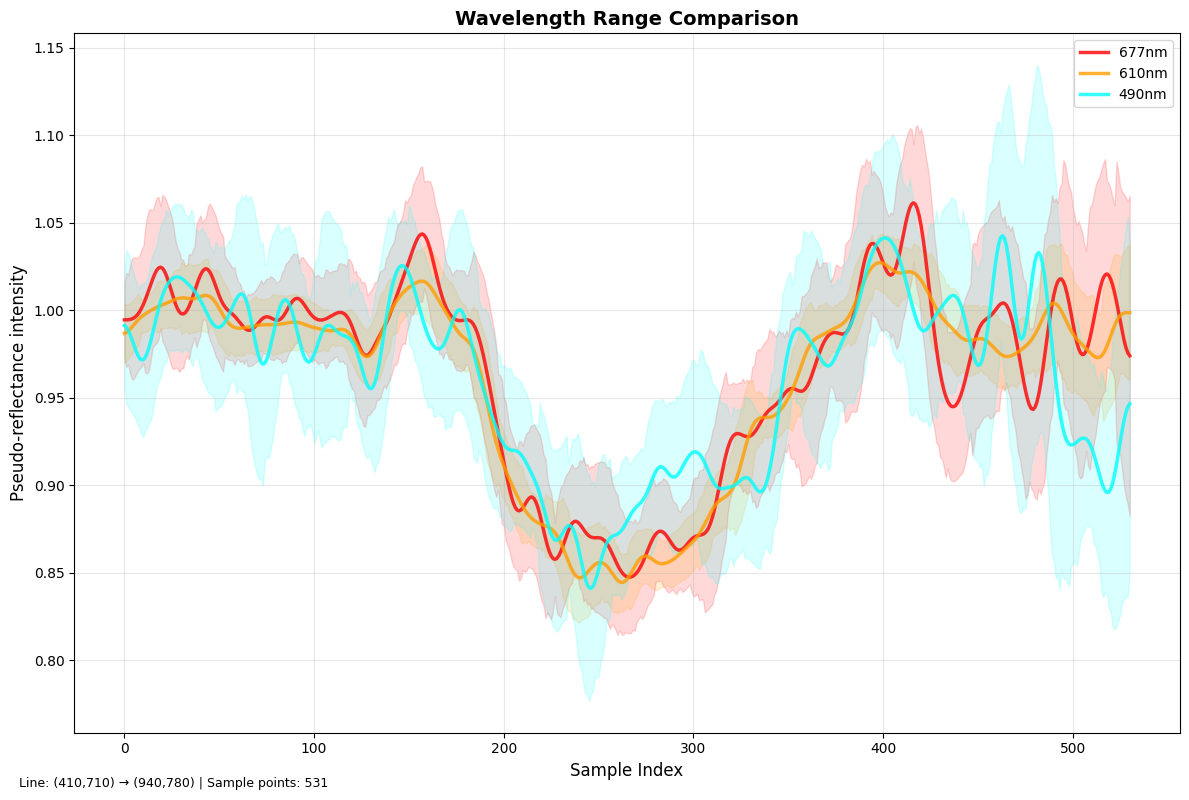

📊 Auto-calculated moving average window: 106 samples (20% of 531 samples)


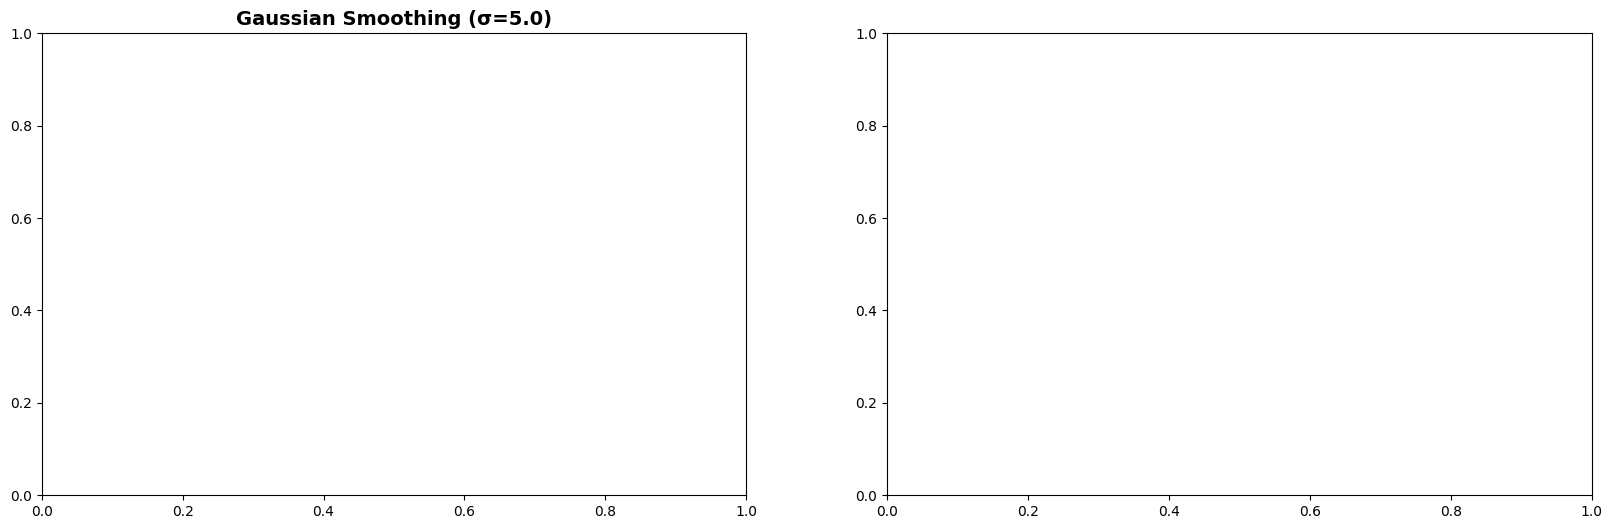

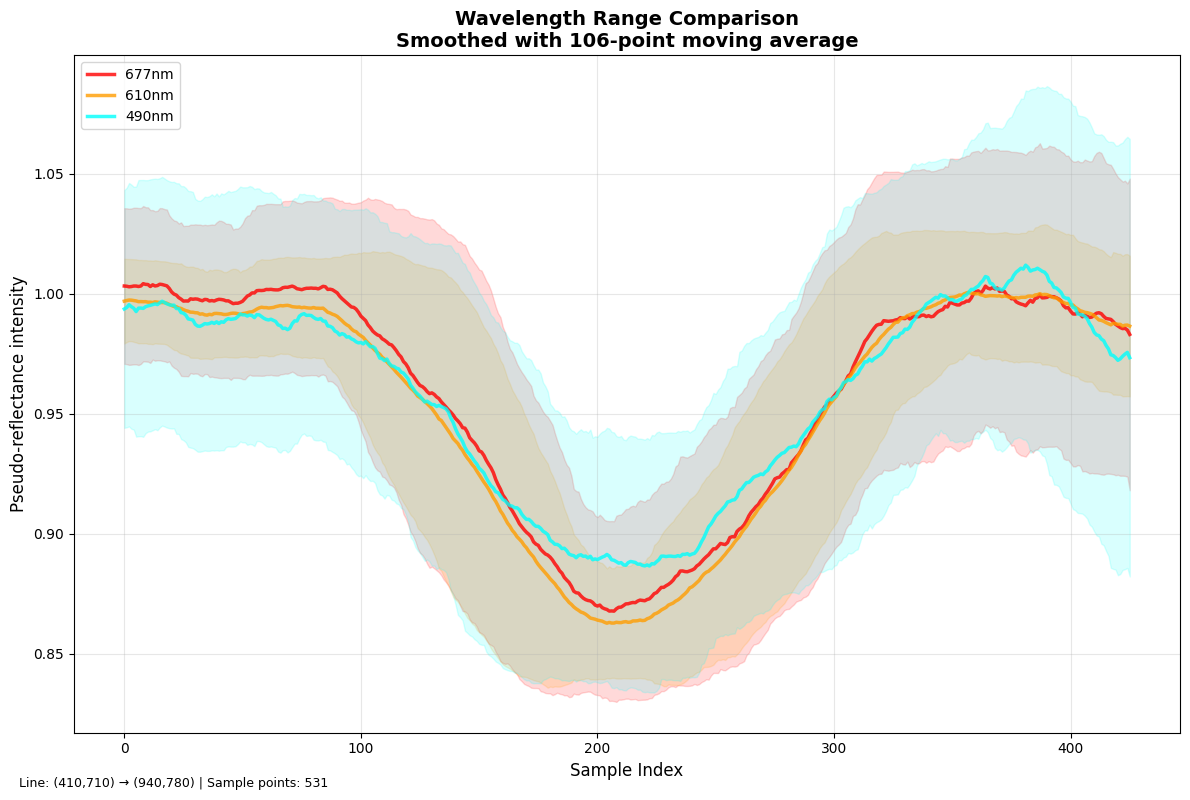

<Figure size 640x480 with 0 Axes>


✅ Test 2 complete: Gaussian vs Moving Average comparison


In [10]:
# Test 2: Compare Gaussian (sigma=5.0) vs Moving Average
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6))

# Left: Gaussian smoothing
plt.sca(ax1)
cube.plot_wavelength_comparison(
    line=lines[0],
    wavelength_ranges=[677, 610, 490],
    smoothing_method="gaussian",
    gaussian_sigma=5.0,
    use_corrected=True,
)
ax1.set_title("Gaussian Smoothing (σ=5.0)", fontsize=14, fontweight="bold")

# Right: Moving average
plt.sca(ax2)
cube.plot_wavelength_comparison(
    line=lines[0],
    wavelength_ranges=[677, 610, 490],
    smoothing_method="moving_average",
    moving_average_percent=20,
    use_corrected=True,
)
ax2.set_title("Moving Average (20%)", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.show()
print("\n✅ Test 2 complete: Gaussian vs Moving Average comparison")

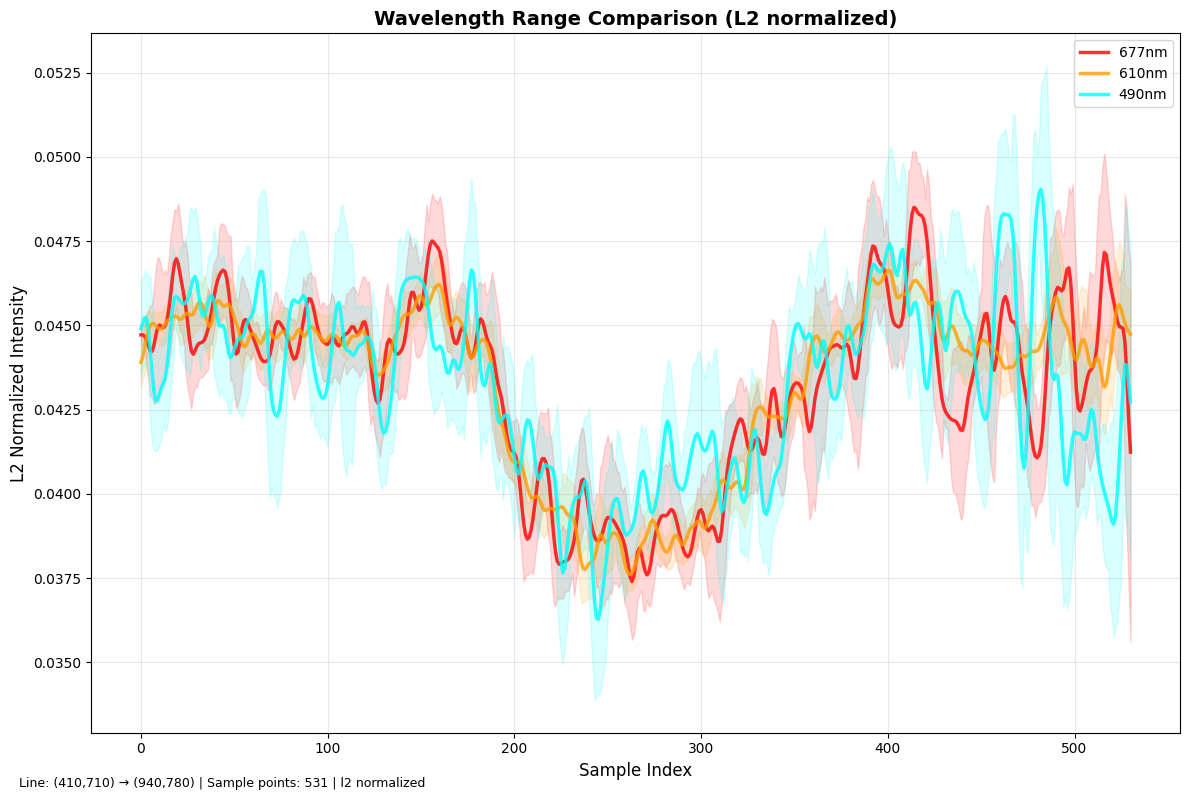


✅ Test 3 complete: L2 normalization
⚠️  Note: L2 normalization makes the intensity vector have Euclidean norm = 1


In [11]:
# Test 3: L2 Normalization
cube.plot_wavelength_comparison(
    line=lines[0],
    wavelength_ranges=[677, 610, 490],
    smoothing_method="gaussian",
    gaussian_sigma=2.0,
    normalize_intensities=True,
    normalization_method="l2",  # NEW: L2 normalization (unit vector)
    use_corrected=True,
)
print("\n✅ Test 3 complete: L2 normalization")
print("⚠️  Note: L2 normalization makes the intensity vector have Euclidean norm = 1")

In [12]:
# # Test 4: Compare all normalization methods
# fig, axes = plt.subplots(2, 2, figsize=(24, 16))

# normalization_methods = [
#     ("minmax", "MinMax [0-1]"),
#     ("zscore", "Z-Score"),
#     ("mean", "Mean-Relative"),
#     ("l2", "L2 (Unit Vector)"),
# ]

# for idx, (method, title) in enumerate(normalization_methods):
#     ax = axes[idx // 2, idx % 2]
#     plt.sca(ax)

#     cube.plot_wavelength_comparison(
#         line=lines[0],
#         wavelength_ranges=[677, 610, 490],
#         smoothing_method="gaussian",
#         gaussian_sigma=2.0,
#         normalize_intensities=True,
#         normalization_method=method,
#         use_corrected=True,
#     )
#     ax.set_title(f"{title} Normalization", fontsize=14, fontweight="bold")

# plt.tight_layout()
# plt.show()
# print("\n✅ Test 4 complete: All normalization methods compared")

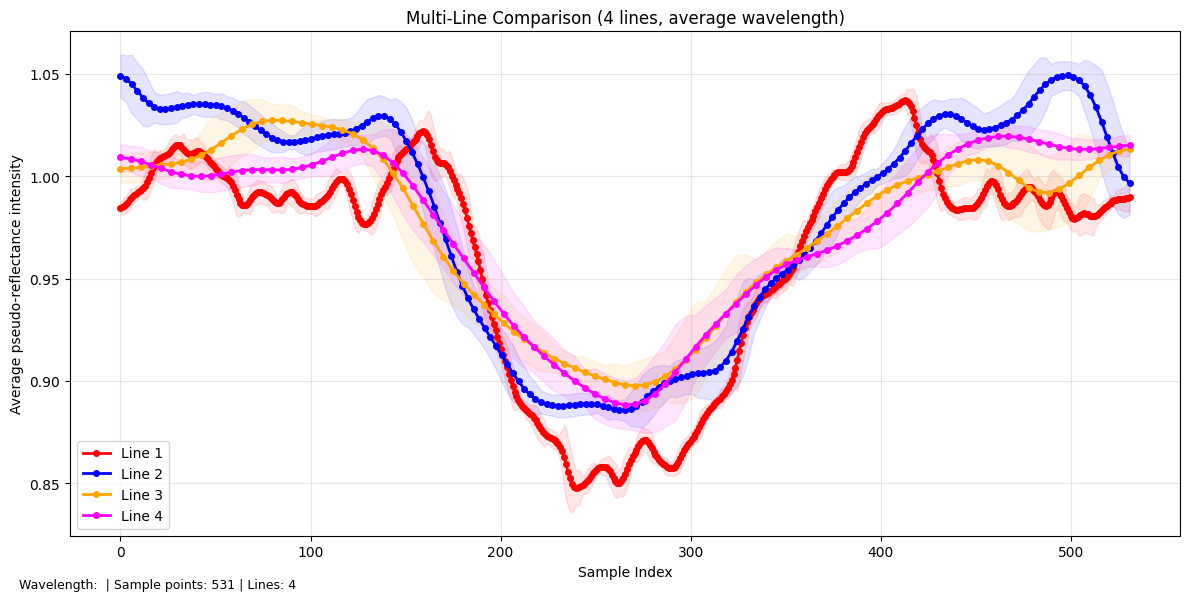


✅ Test 5 complete: Line intensity profiles with Gaussian smoothing


In [13]:
# Test 5: Line intensity profiles with Gaussian smoothing
cube.plot_line_intensity_profile(
    perimeter_line=lines,
    use_average=True,
    wavelength_range="all",
    smoothing_method="gaussian",  # NEW: Use Gaussian instead of moving average
    gaussian_sigma=3.0,  # NEW: Sigma parameter
    show_markers=False,
    line_labels=labels,
    line_colors=colors,
    use_corrected=True,
)
print("\n✅ Test 5 complete: Line intensity profiles with Gaussian smoothing")

# 🆕 Test New Sparse Sampling Feature

**Purpose:** Compare old (oversampling/duplication) vs new (sparse sampling) methods

The new `use_sparse_sampling=True` (now default) avoids pixel duplication for short lines!

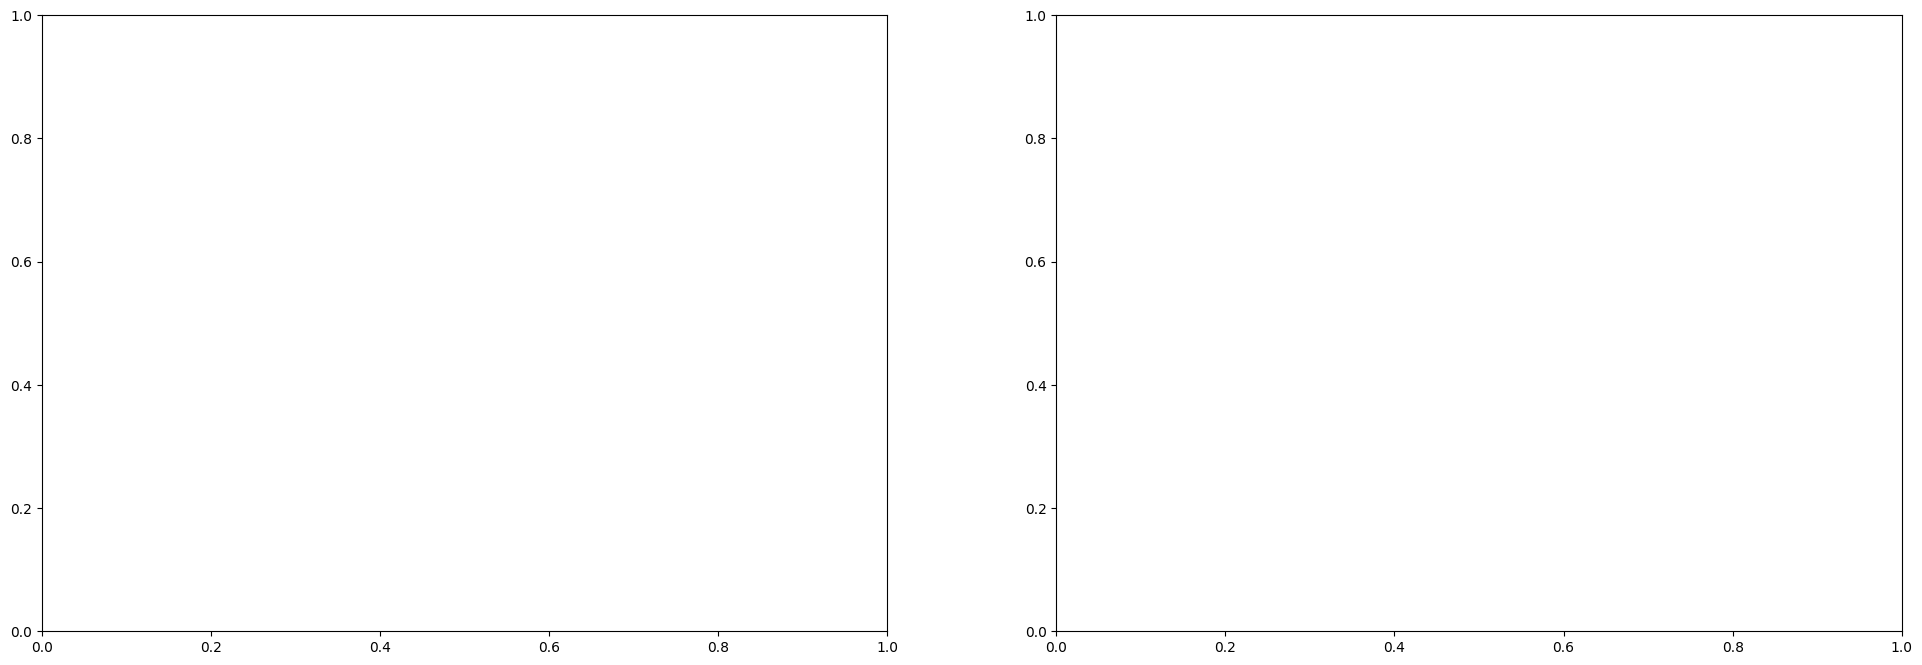

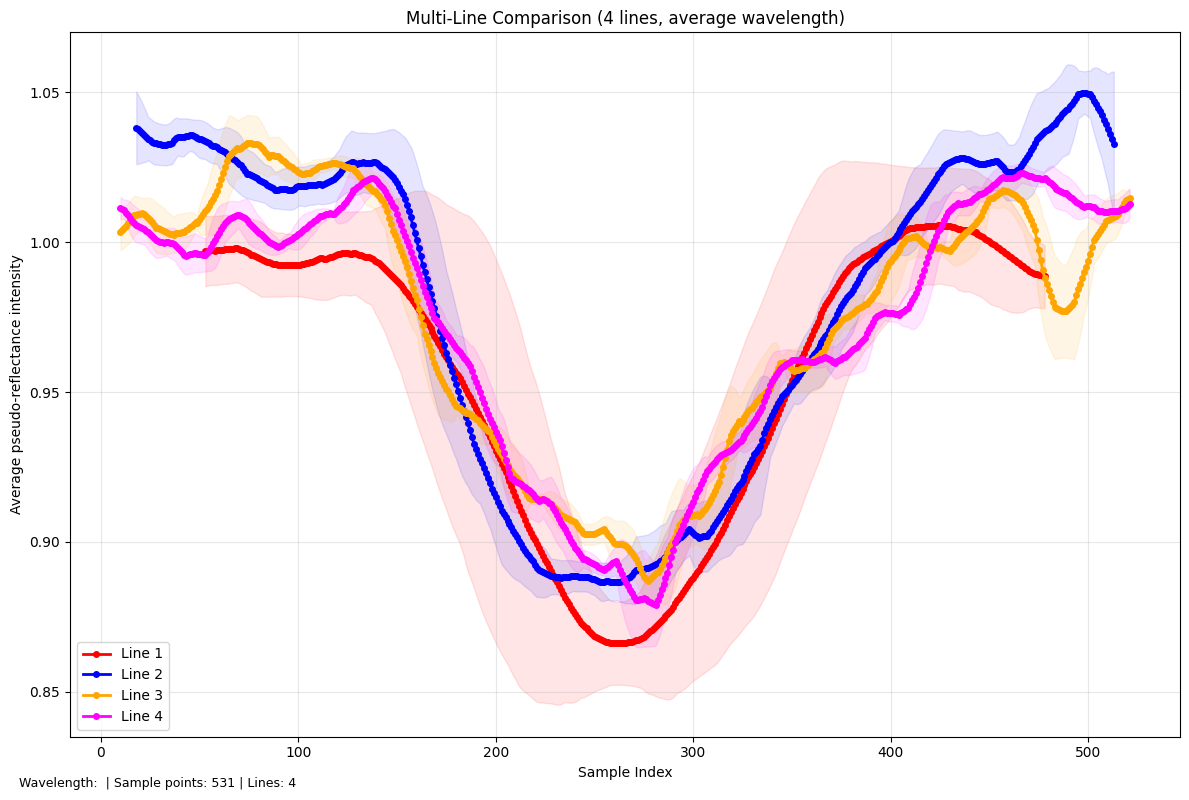

c:\conda_envs\my_env\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


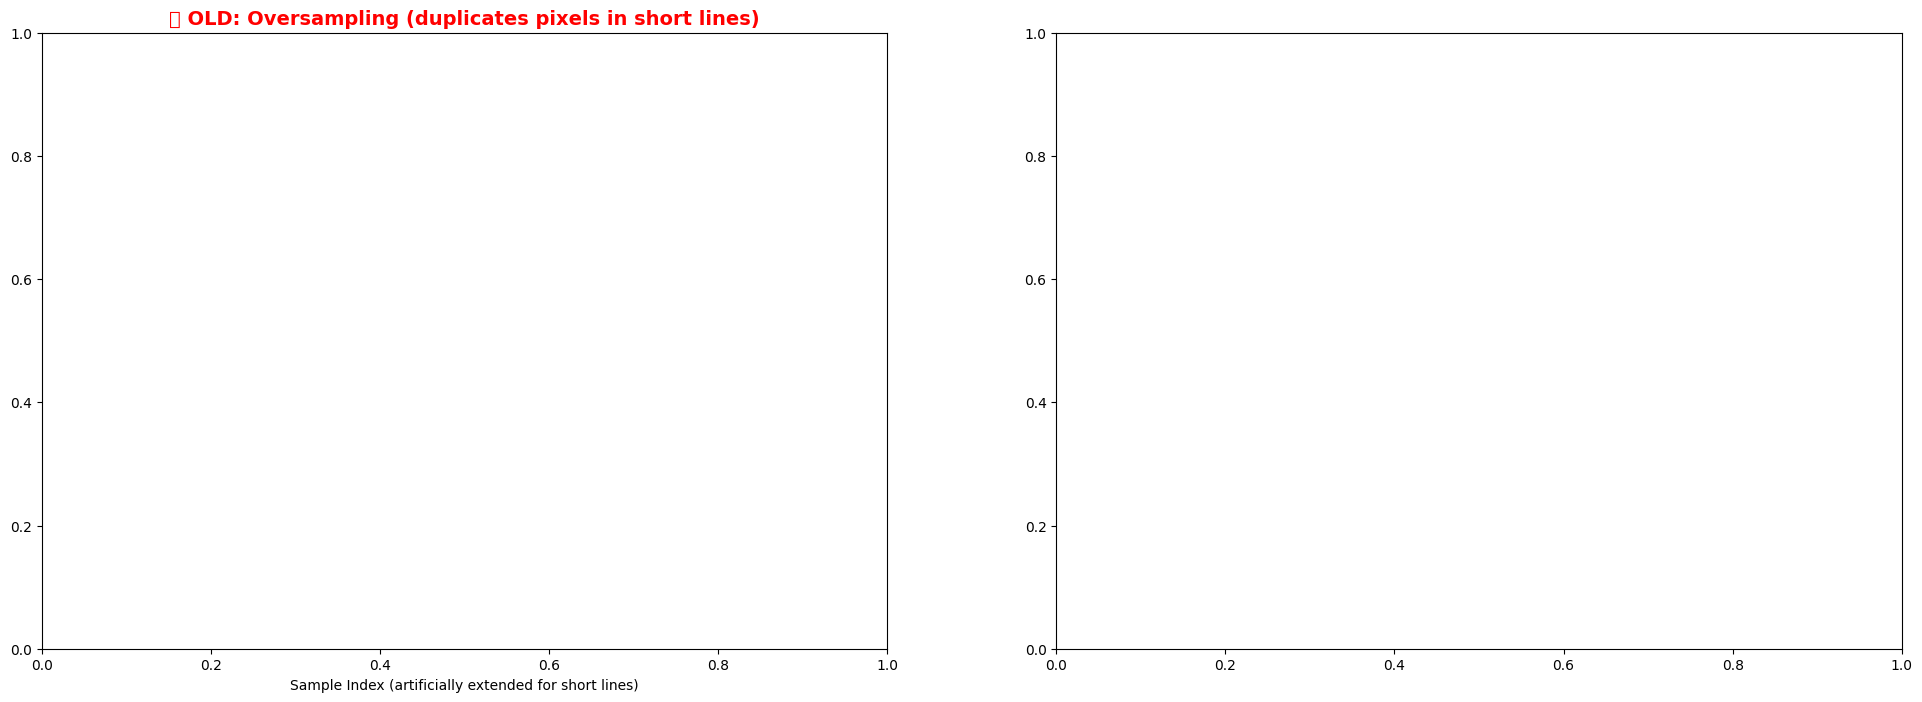

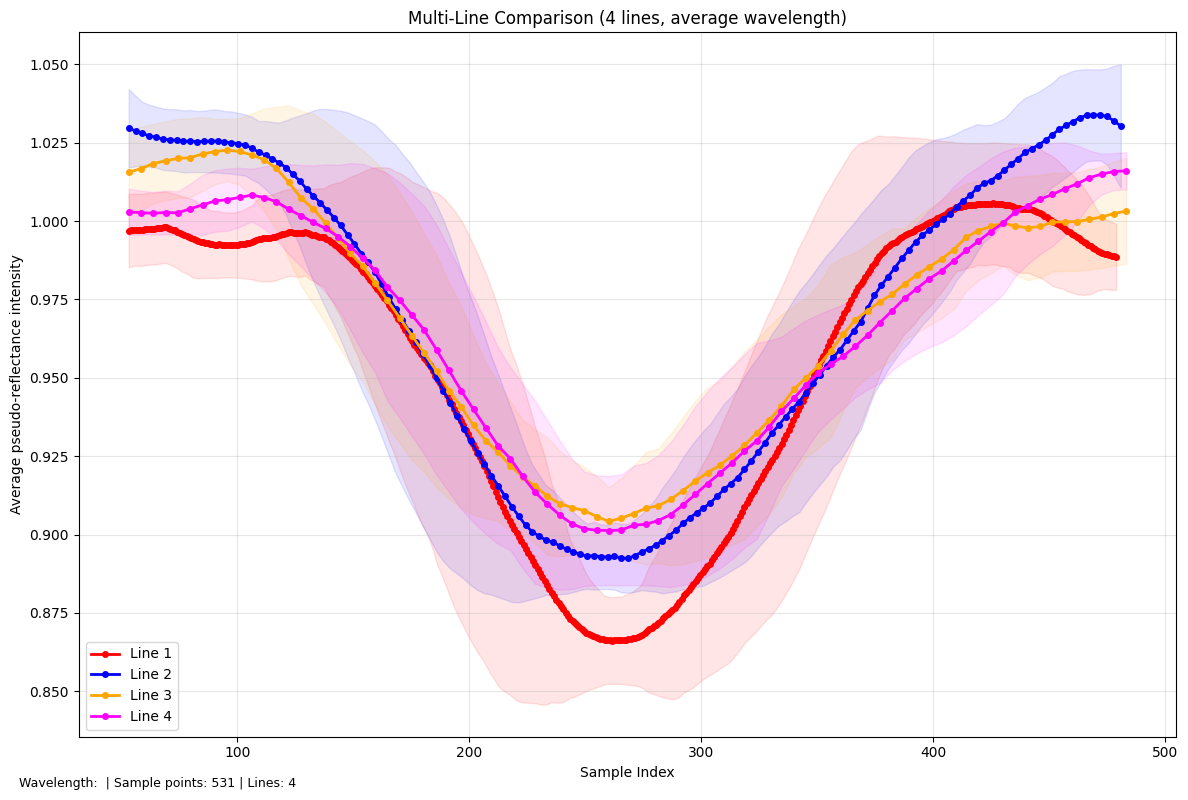

<Figure size 640x480 with 0 Axes>


📊 LINE LENGTHS:
   Line 1: 531 pixels
   Line 2: 181 pixels
   Line 3: 101 pixels
   Line 4: 101 pixels

⚠️  OLD METHOD: All lines resampled to 540 points → short lines have duplicated pixels
✅ NEW METHOD: Each line keeps its actual pixel count → no artificial duplication


In [14]:
# Test: Compare OLD (oversampling) vs NEW (sparse sampling)
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(24, 8))

# LEFT: OLD METHOD (oversampling with duplication)
plt.sca(ax1)
cube.plot_line_intensity_profile(
    perimeter_line=lines,
    use_average=True,
    moving_average_percent=20,
    wavelength_range="all",
    use_corrected=True,
    line_labels=labels,
    line_colors=colors,
    use_sparse_sampling=False,  # OLD: causes pixel duplication
    figsize=(12, 8),
)
ax1.set_title(
    "❌ OLD: Oversampling (duplicates pixels in short lines)",
    fontsize=14,
    fontweight="bold",
    color="red",
)
ax1.set_xlabel("Sample Index (artificially extended for short lines)")

# RIGHT: NEW METHOD (sparse sampling, no duplication)
plt.sca(ax2)
cube.plot_line_intensity_profile(
    perimeter_line=lines,
    use_average=True,
    moving_average_percent=20,
    wavelength_range="all",
    use_corrected=True,
    line_labels=labels,
    line_colors=colors,
    use_sparse_sampling=True,  # NEW: preserves original pixels
    sparse_normalize_x=True,  # Scale X so all lines end at same position
    sparse_smoothing="before",  # Smooth before sparse placement
    figsize=(12, 8),
)
ax2.set_title(
    "✅ NEW: Sparse Sampling (preserves original data)",
    fontsize=14,
    fontweight="bold",
    color="green",
)
ax2.set_xlabel("Normalized Distance (no pixel duplication)")

plt.tight_layout()
plt.show()

print("\n" + "=" * 80)
print("📊 LINE LENGTHS:")
for i, line in enumerate(lines, 1):
    (s1, t1), (s2, t2) = line
    length = max(abs(t2 - t1), abs(s2 - s1)) + 1
    print(f"   Line {i}: {length} pixels")
print("=" * 80)
print(
    "\n⚠️  OLD METHOD: All lines resampled to 540 points → short lines have duplicated pixels"
)
print(
    "✅ NEW METHOD: Each line keeps its actual pixel count → no artificial duplication"
)

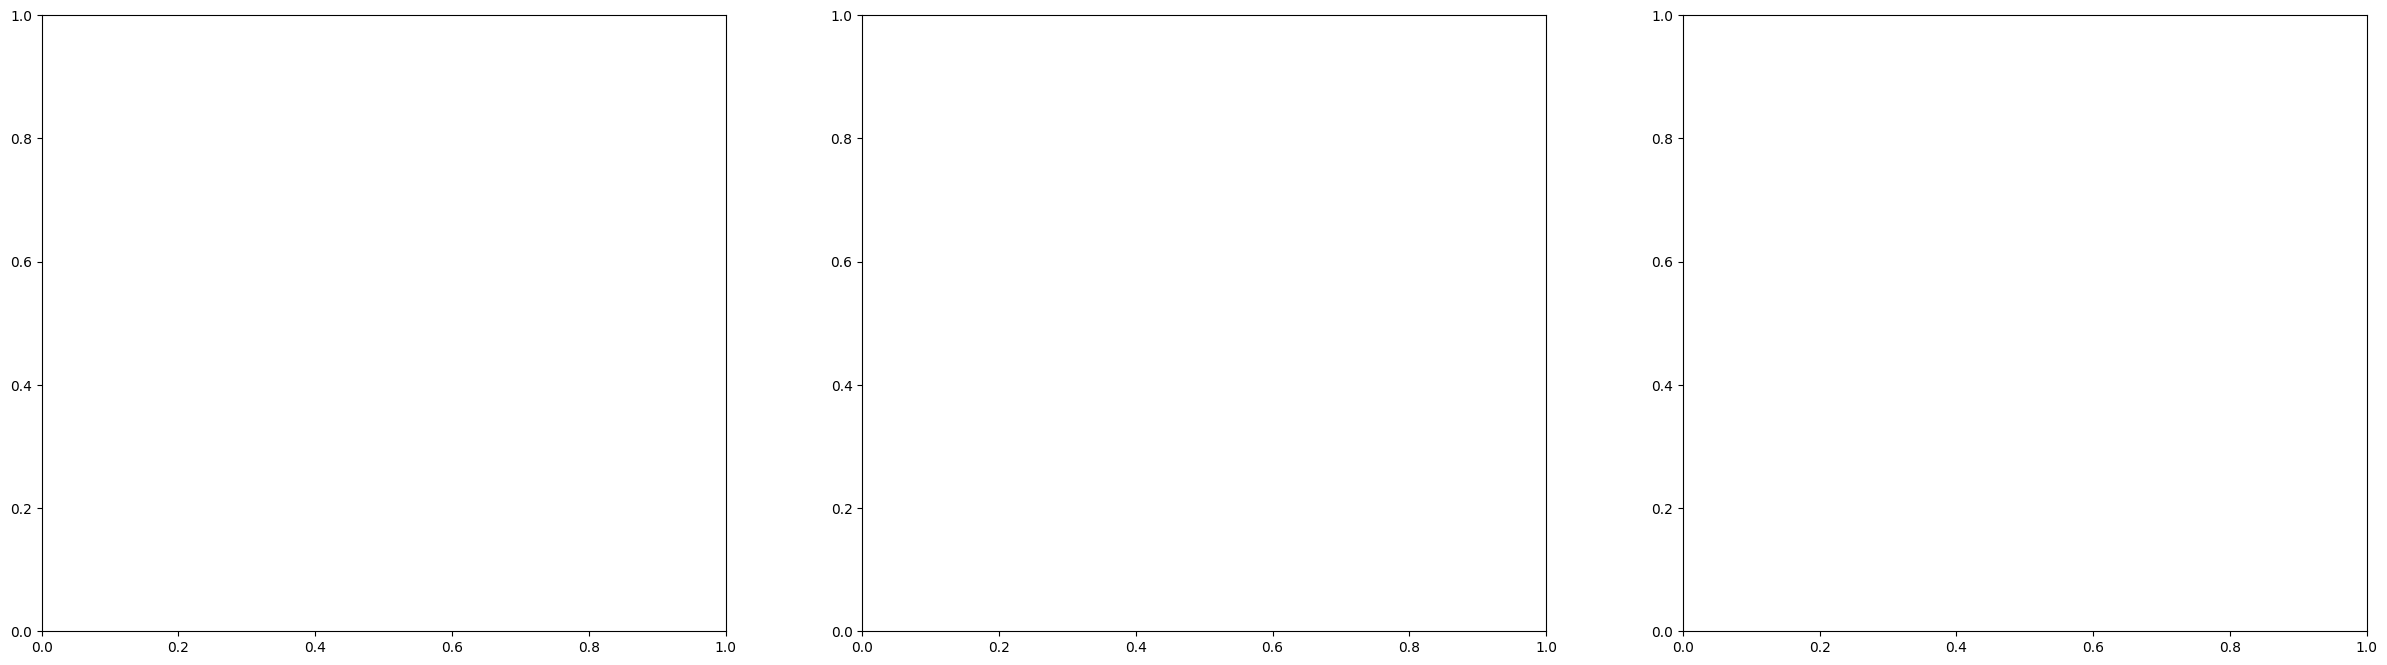

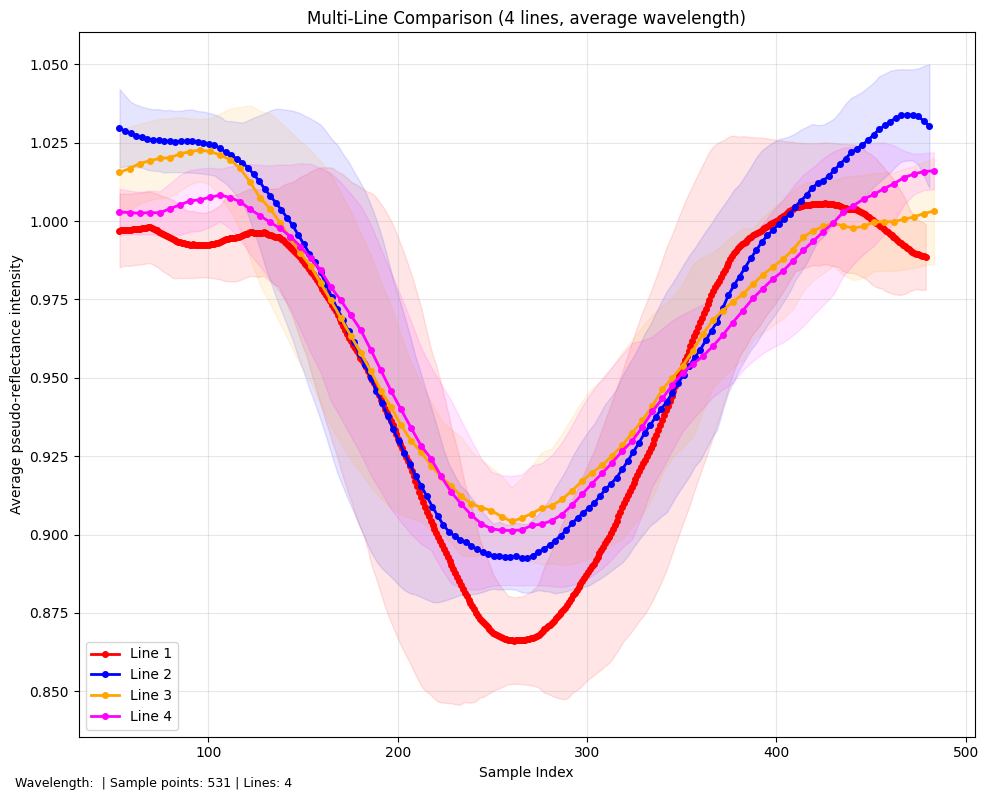

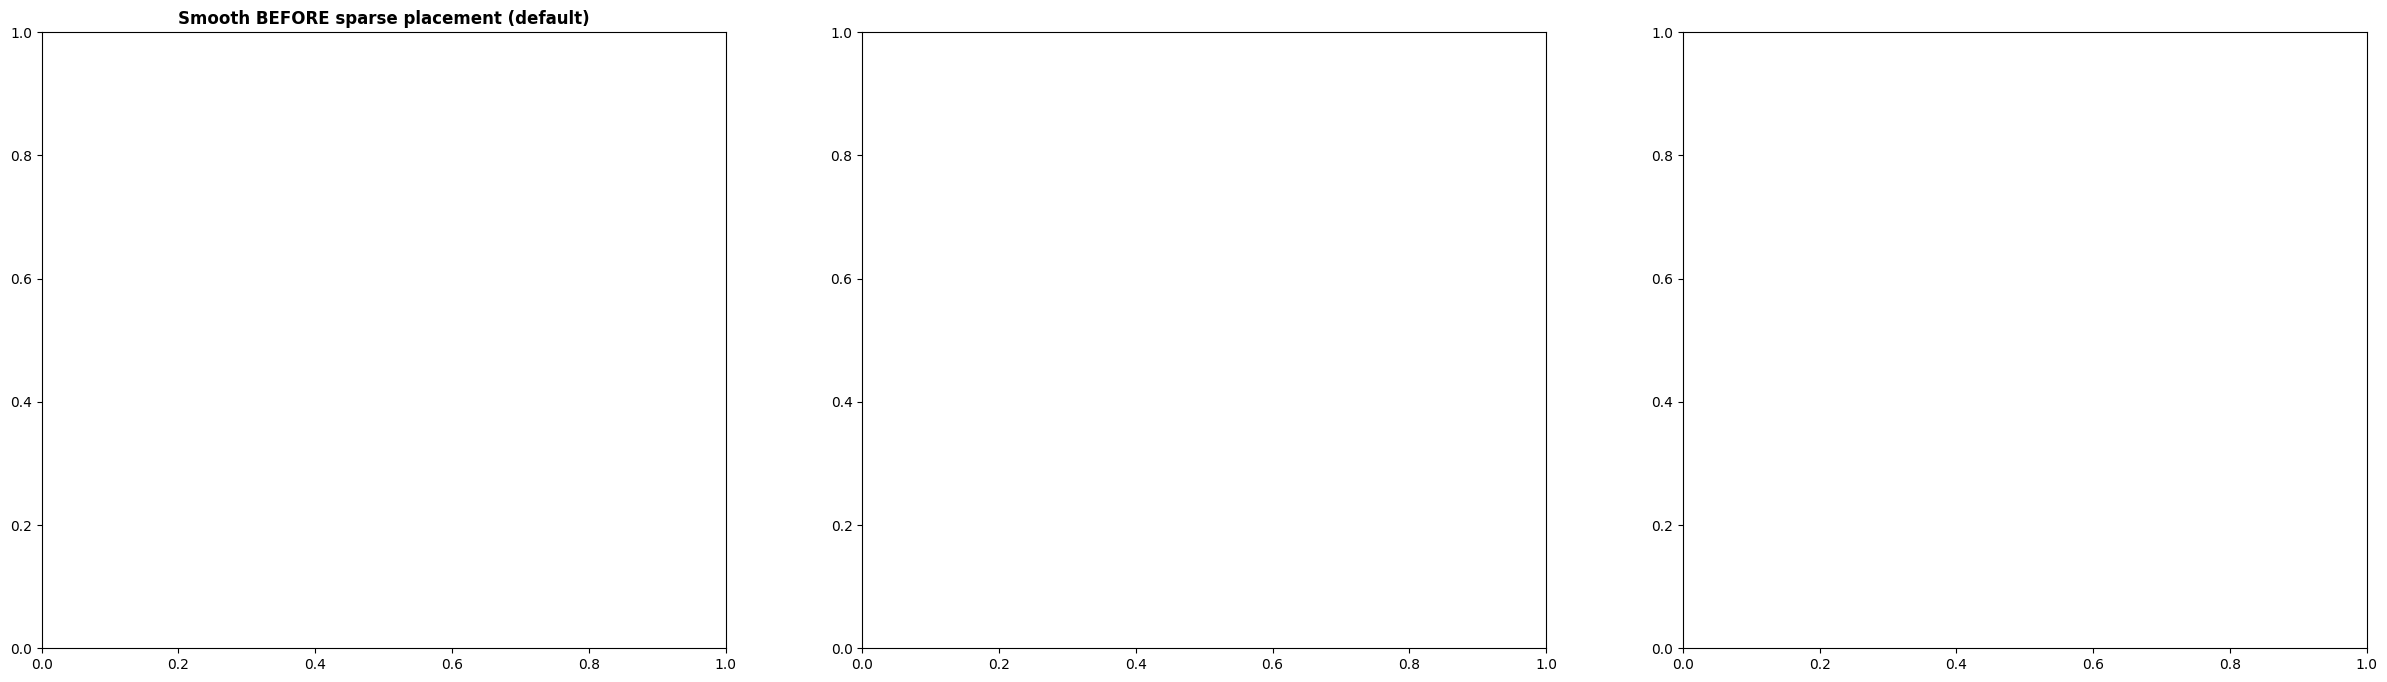

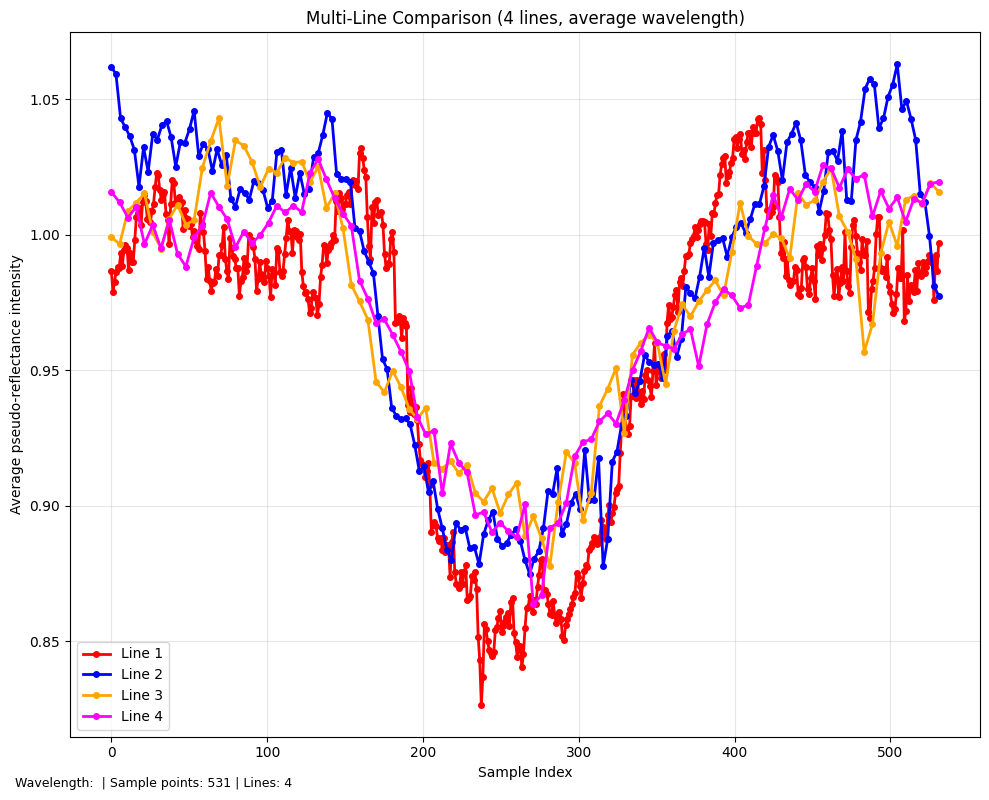

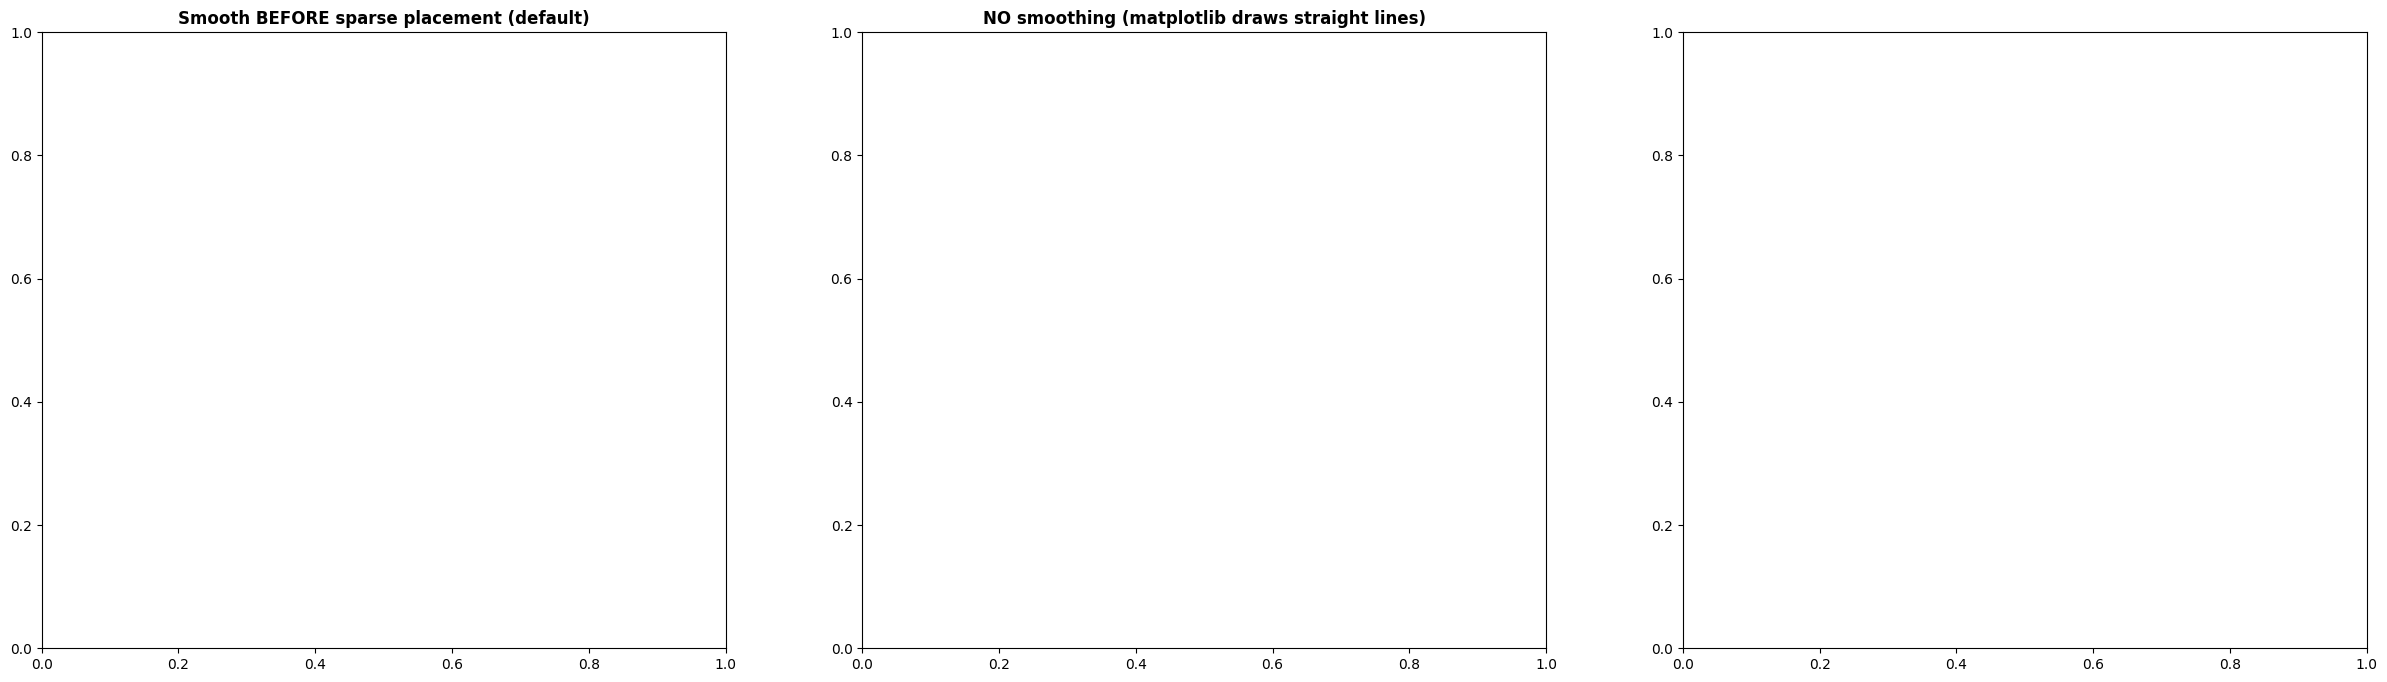

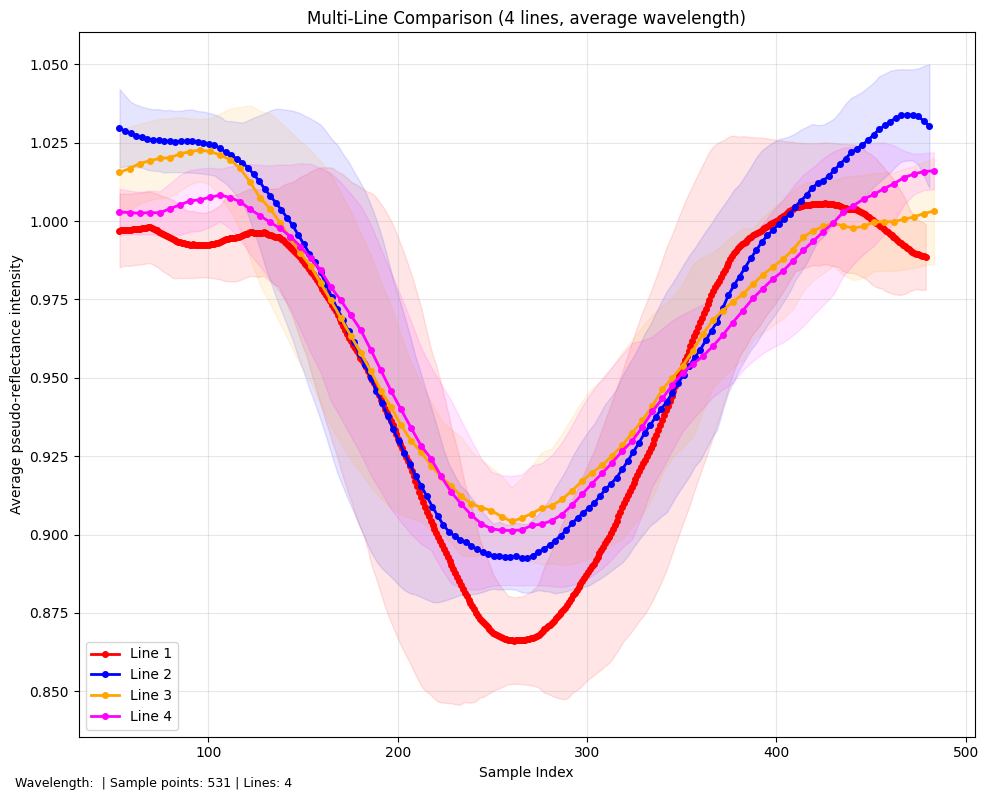

<Figure size 640x480 with 0 Axes>


📝 SMOOTHING OPTIONS EXPLAINED:
1️⃣  'before' (default): Apply smoothing to original pixel values
    → Smooth data, then place at sparse X positions
    → Best for preserving features while reducing noise

2️⃣  'none': No smoothing applied
    → Raw pixel values, matplotlib connects with straight lines
    → Most honest representation, shows actual sampling

3️⃣  'after': Apply smoothing after sparse placement (NOT RECOMMENDED)
    → Place sparse points, then smooth in X-space
    → May create artifacts, use only for experimentation


In [15]:
# Test: Compare different smoothing options with sparse sampling
fig, axes = plt.subplots(1, 3, figsize=(30, 8))

smoothing_options = [
    ("before", "Smooth BEFORE sparse placement (default)"),
    ("none", "NO smoothing (matplotlib draws straight lines)"),
    ("after", "Smooth AFTER sparse placement (experimental)"),
]

for idx, (smooth_mode, title) in enumerate(smoothing_options):
    plt.sca(axes[idx])
    cube.plot_line_intensity_profile(
        perimeter_line=lines,
        use_average=True,
        moving_average_percent=20,
        wavelength_range="all",
        use_corrected=True,
        line_labels=labels,
        line_colors=colors,
        use_sparse_sampling=True,
        sparse_normalize_x=True,
        sparse_smoothing=smooth_mode,  # Test different smoothing modes
        figsize=(10, 8),
    )
    axes[idx].set_title(title, fontsize=12, fontweight="bold")

plt.tight_layout()
plt.show()

print("\n" + "=" * 80)
print("📝 SMOOTHING OPTIONS EXPLAINED:")
print("=" * 80)
print("1️⃣  'before' (default): Apply smoothing to original pixel values")
print("    → Smooth data, then place at sparse X positions")
print("    → Best for preserving features while reducing noise")
print()
print("2️⃣  'none': No smoothing applied")
print("    → Raw pixel values, matplotlib connects with straight lines")
print("    → Most honest representation, shows actual sampling")
print()
print("3️⃣  'after': Apply smoothing after sparse placement (NOT RECOMMENDED)")
print("    → Place sparse points, then smooth in X-space")
print("    → May create artifacts, use only for experimentation")
print("=" * 80)

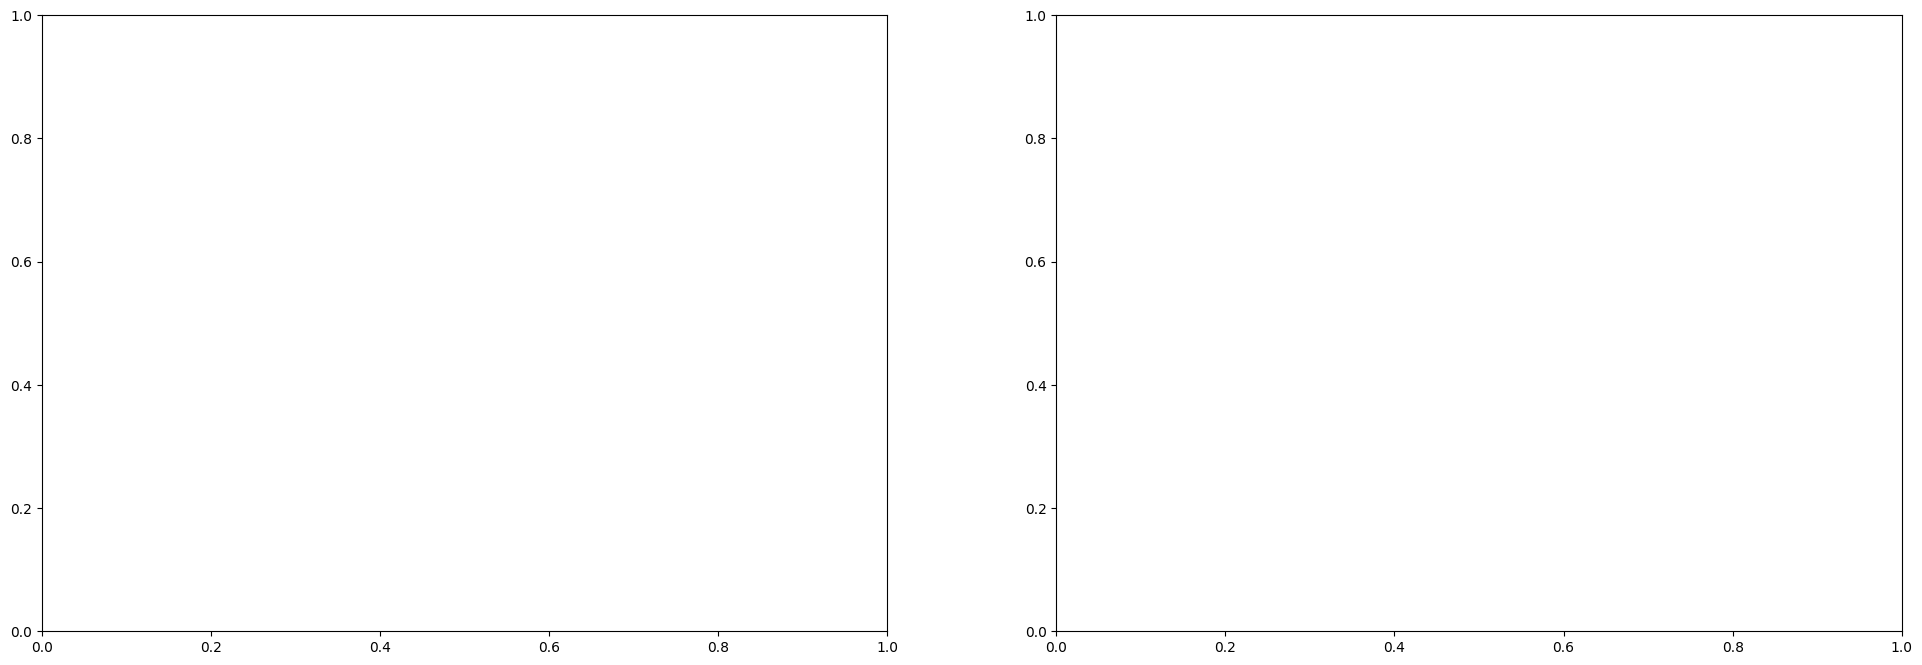

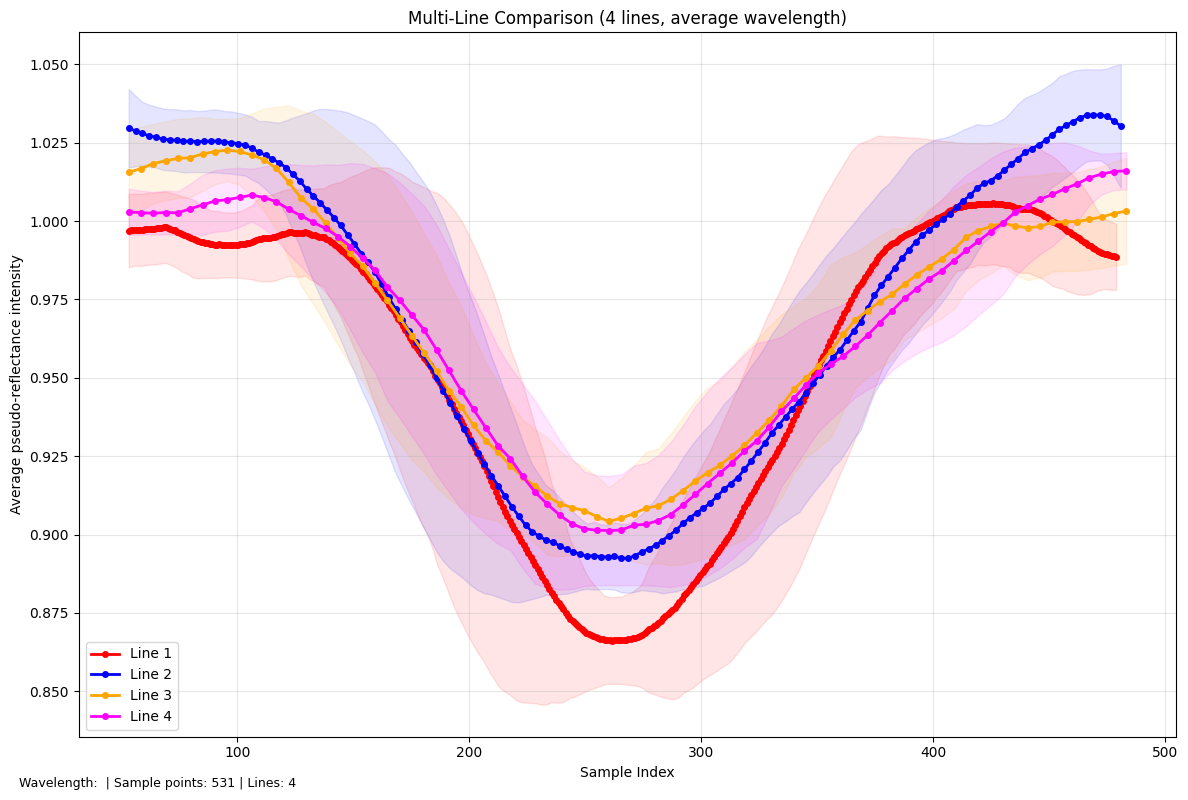

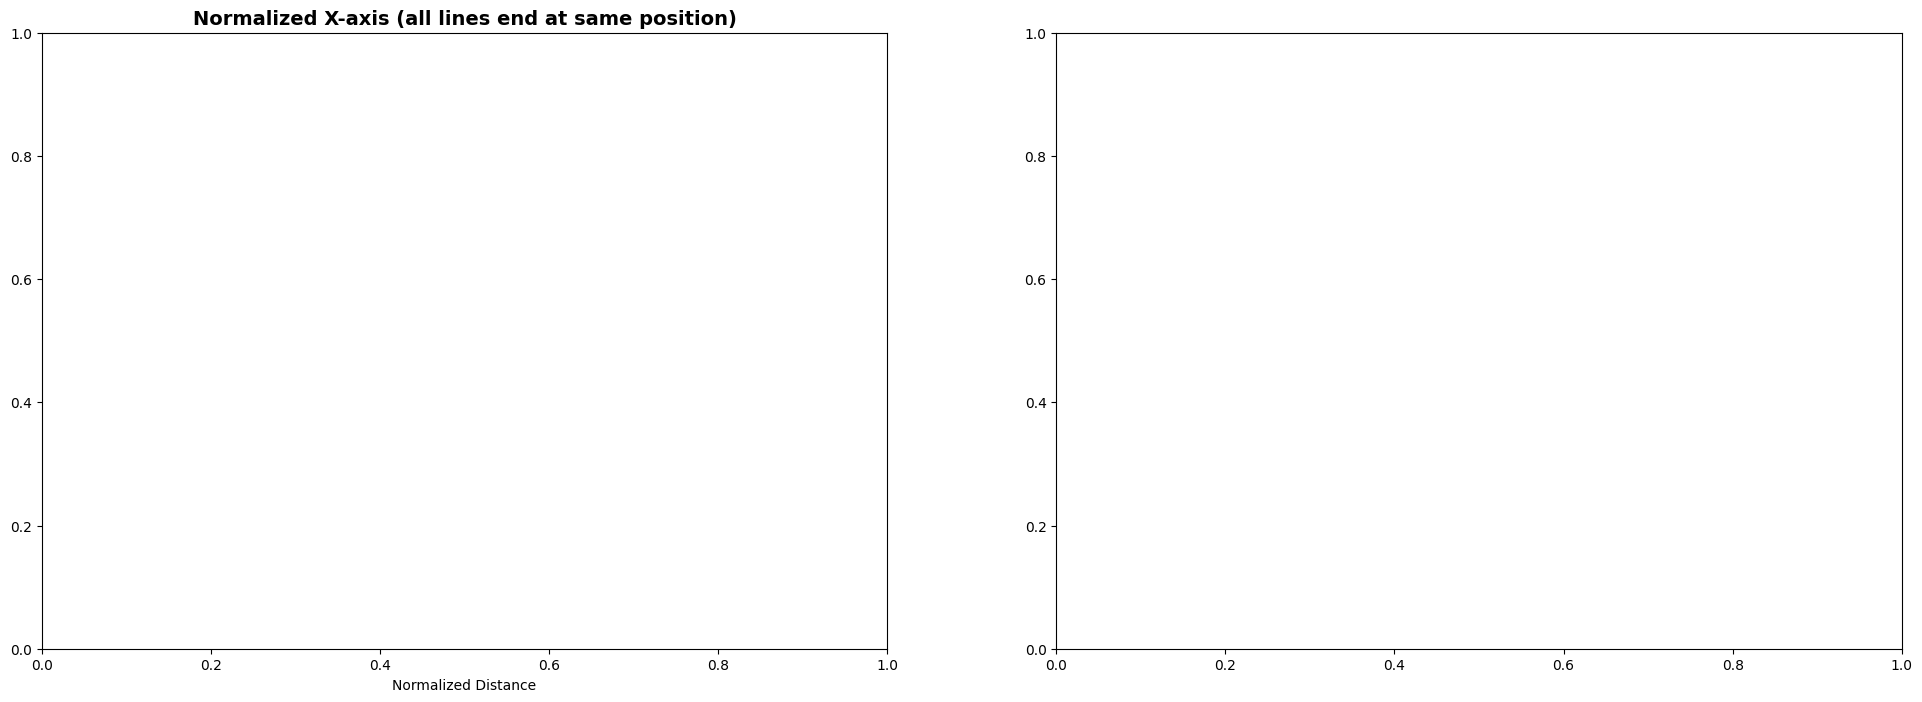

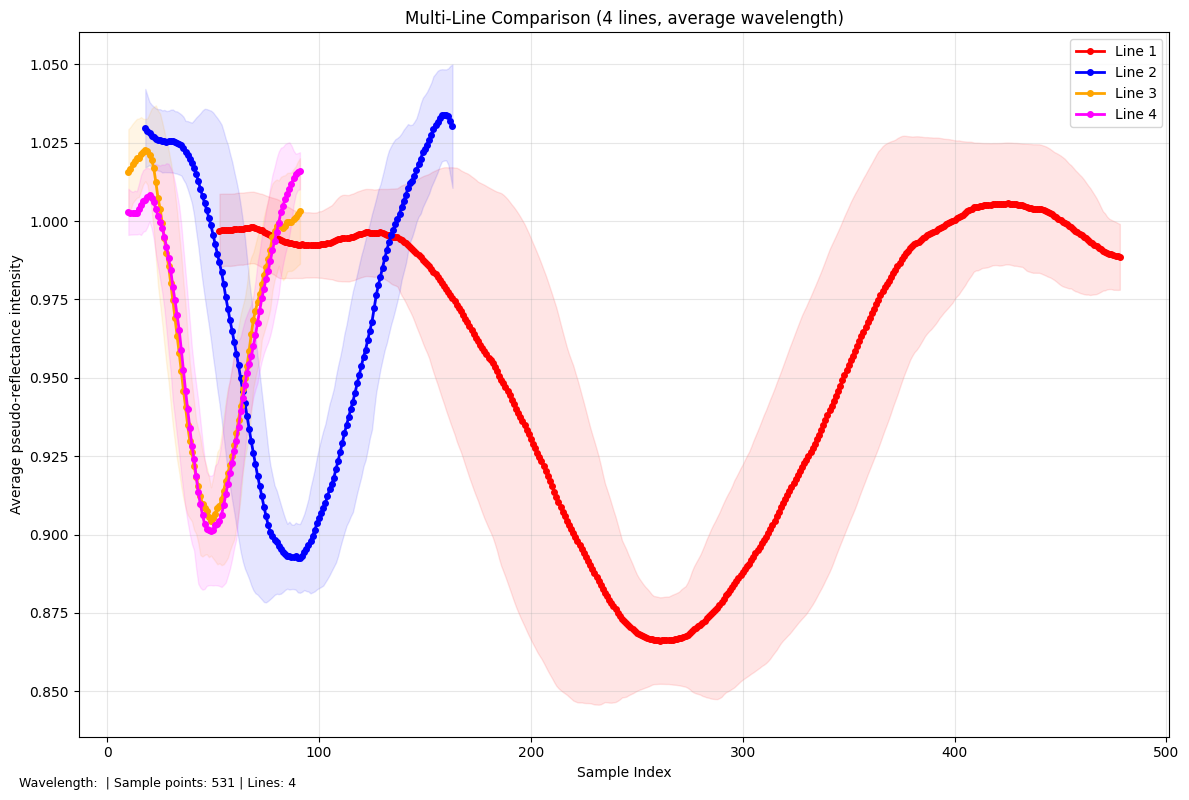

<Figure size 640x480 with 0 Axes>


📏 X-AXIS SCALING OPTIONS:
✅ sparse_normalize_x=True (default):
   → All lines scaled to end at same X position
   → Better for visual comparison
   → X-axis shows 'normalized distance'

📐 sparse_normalize_x=False:
   → Lines end at their actual pixel length
   → More honest about spatial extent
   → Shorter lines visibly end earlier


In [16]:
# Test: X-axis normalization options
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(24, 8))

# LEFT: X-axis normalized (all lines end at same position)
plt.sca(ax1)
cube.plot_line_intensity_profile(
    perimeter_line=lines,
    use_average=True,
    moving_average_percent=20,
    wavelength_range="all",
    use_corrected=True,
    line_labels=labels,
    line_colors=colors,
    use_sparse_sampling=True,
    sparse_normalize_x=True,  # Scale X so all end at same position
    sparse_smoothing="before",
    figsize=(12, 8),
)
ax1.set_title(
    "Normalized X-axis (all lines end at same position)", fontsize=14, fontweight="bold"
)
ax1.set_xlabel("Normalized Distance")

# RIGHT: X-axis NOT normalized (lines end at actual length)
plt.sca(ax2)
cube.plot_line_intensity_profile(
    perimeter_line=lines,
    use_average=True,
    moving_average_percent=20,
    wavelength_range="all",
    use_corrected=True,
    line_labels=labels,
    line_colors=colors,
    use_sparse_sampling=True,
    sparse_normalize_x=False,  # Lines end at their actual length
    sparse_smoothing="before",
    figsize=(12, 8),
)
ax2.set_title(
    "Actual X-axis (shorter lines end earlier)", fontsize=14, fontweight="bold"
)
ax2.set_xlabel("Actual Distance (pixels)")

plt.tight_layout()
plt.show()

print("\n" + "=" * 80)
print("📏 X-AXIS SCALING OPTIONS:")
print("=" * 80)
print("✅ sparse_normalize_x=True (default):")
print("   → All lines scaled to end at same X position")
print("   → Better for visual comparison")
print("   → X-axis shows 'normalized distance'")
print()
print("📐 sparse_normalize_x=False:")
print("   → Lines end at their actual pixel length")
print("   → More honest about spatial extent")
print("   → Shorter lines visibly end earlier")
print("=" * 80)

# 📖 Methods Documentation: Spatial Intensity Profile Analysis

---

## Overview

This notebook performs **spatial intensity profile analysis** of hyperspectral data along user-defined transect lines to characterize seafloor spectral variations. The analysis extracts intensity profiles at specific wavelengths, applies smoothing, and visualizes spectral gradients to identify seafloor features (rocks, munitions, substrate changes).

**Key Analysis Steps:**
1. Load hyperspectral transect data
2. Apply illumination correction and spectral filtering
3. Define analysis lines across regions of interest
4. Extract and smooth intensity profiles along lines
5. Compare spectral responses at multiple wavelengths
6. Visualize RGB composite with overlaid transect lines

---

## Section 1: Data Preprocessing

### 1.1 Hyperspectral Data Loading

**Purpose:** Load georeferenced hyperspectral datacube and extract spatial/spectral metadata.

**Input Data:**
- **File:** `rad_uhi_20241029_115057_5` (single file from transect 057)
- **Format:** HDF5 with georeferencing metadata
- **Dimensions:** $T \times S \times B$ where
  - $T = 2462$ track points (along-flight direction)
  - $S = 968$ slit positions (across-swath direction)
  - $B = 210$ spectral bands (490–700 nm range after filtering)

**Loading Process:**
```python
transect = load_transect(config.TRANSECT_057_OUTPUT)
cube = transect.select_files(["rad_uhi_20241029_115057_5"])
```

**Data Structure:**
- `cube.data`: Radiance datacube $\mathbf{L} \in \mathbb{R}^{T \times S \times B}$ (μW/cm²/sr/nm)
- `cube.wavelengths`: Wavelength vector $\boldsymbol{\lambda} \in \mathbb{R}^B$ (nm)
- `cube.E`, `cube.N`: NED coordinates $E,N \in \mathbb{R}^{T \times S}$ (m)

---

### 1.2 Illumination Correction

**Purpose:** Remove along-track illumination gradient caused by changing sun angle and water clarity.

**Algorithm:** Rolling median normalization (Section 2.3 from notebook 6 documentation)

**Implementation:**
```python
cube.apply_illumination_correction_v2(window_size=500)
```

**Mathematical Formulation:**

For each spatial pixel $(t, s)$ and wavelength band $\lambda$:

$$
L_{\text{corr}}(t, s, \lambda) = L_{\text{raw}}(t, s, \lambda) - \tilde{L}_t(\lambda) + \bar{\tilde{L}}(\lambda)
$$

where:
- $\tilde{L}_t(\lambda)$ = rolling median at track position $t$ (window = 500 pixels)
- $\bar{\tilde{L}}(\lambda)$ = global median across entire transect
- Window = 500 pixels ≈ 25 m along-track distance

**Effect:**
- Removes slow variations in illumination (cloud shadows, water turbidity changes)
- Preserves local spectral features (rocks, munitions, substrate)
- Maintains relative spectral shape for classification

---

### 1.3 UHI Alignment Adjustment

**Purpose:** Correct spatial misalignment between hyperspectral georeferencing and MBES bathymetry.

**Correction Applied:**
```python
cube.adjust_uhi_alignment(dx=-0.05, dy=-3.0)
```

**Transformation:**

$$
\begin{aligned}
E_{\text{adjusted}} &= E_{\text{original}} + \Delta x = E + (-0.05) \\
N_{\text{adjusted}} &= N_{\text{original}} + \Delta y = N + (-3.0)
\end{aligned}
$$

**Alignment Parameters:**
- $\Delta x = -0.05$ m (westward shift)
- $\Delta y = -3.0$ m (southward shift)
- Determined empirically by co-registering HSI with MBES residuals

**Why Needed:**
- IMU/GPS errors accumulate during georeferencing
- Hyperspectral push-broom geometry sensitive to pointing errors
- Alignment ensures accurate overlay with MBES bathymetry

---

### 1.4 Wavelength Filtering

**Purpose:** Restrict analysis to visible wavelength range with stable underwater transmission.

**Filter Applied:**
```python
cube.apply_wavelength_filter(wavelength_range=(490, 700))
```

**Wavelength Range:**
- **Lower bound:** 490 nm (blue-cyan edge)
- **Upper bound:** 700 nm (deep red edge)
- **Range:** 210 nm bandwidth

**Spectral Windows:**
- **Blue-green (490–550 nm):** Best underwater penetration, sensitive to water column
- **Green-yellow (550–600 nm):** Moderate attenuation, sensitive to chlorophyll/algae
- **Orange-red (600–700 nm):** Strong attenuation, sensitive to surface features/depth

**Why This Range:**
- Below 490 nm: Low signal-to-noise, strong Rayleigh scattering
- Above 700 nm: Severe water absorption, poor seafloor signal
- 490–700 nm: Optimal balance of penetration and information content

**Output:**
- `cube.wavelengths`: Filtered to 210 bands spanning 490–700 nm
- `cube.data`: Truncated to selected wavelength indices

---

## Section 2: Transect Line Definition and Profile Extraction

### 2.1 Analysis Line Specification

**Purpose:** Define spatial transects across features of interest for intensity profile extraction.

**Line Definition Format:**

Each line specified as a pair of endpoints in image coordinates:
```python
line = [(start_track, start_slit), (end_track, end_slit)]
```

**Example Lines:**
```python
line1 = [(410, 710), (940, 780)]   # Diagonal across target region
line2 = [(340, 1030), (340, 1210)] # Vertical transect
line3 = [(250, 890), (250, 990)]   # Short vertical section
line4 = [(300, 1358), (300, 1458)] # Another vertical section

lines = [line1, line2, line3, line4]
colors = ["red", "blue", "orange", "magenta"]
labels = ["Line 1", "Line 2", "Line 3", "Line 4"]
```

**Coordinate System:**
- **Track dimension** (first index): Along-flight direction, range [576, 1566] after cropping
- **Slit dimension** (second index): Across-swath direction, range [0, 967]
- **Units:** Pixel indices (not physical coordinates)

**Line Selection Criteria:**
- Cross known targets (munitions, rocks, substrate boundaries)
- Avoid survey edges (poor data quality)
- Mix orientations (along-track, across-track, diagonal) to capture different gradients
- Stay within illumination-corrected track range

**Visualization:**

Lines overlaid on RGB composite:
```python
cube.plot_georef(
    perimeter_line=lines,
    line_colors=colors,
    line_width=3,
    line_labels=labels
)
```

---

### 2.2 Intensity Profile Extraction

**Purpose:** Extract spectral intensity values along defined transect lines.

**Method:** `plot_line_intensity_profile()`

**Extraction Algorithm:**

For a line from $(t_0, s_0)$ to $(t_1, s_1)$:

**Step 1: Parametric line interpolation**

Sample $N$ points along line using Bresenham's algorithm:
$$
\begin{aligned}
t_i &= t_0 + i \cdot \frac{t_1 - t_0}{N-1} \\
s_i &= s_0 + i \cdot \frac{s_1 - s_0}{N-1}
\end{aligned}
$$
for $i = 0, 1, \ldots, N-1$ where $N = \max(|t_1-t_0|, |s_1-s_0|)$

**Step 2: Bilinear interpolation**

For non-integer coordinates $(t_i, s_i)$:
$$
I(t_i, s_i, \lambda) = \sum_{p,q} w_{pq} \cdot L(\lfloor t_i \rfloor + p, \lfloor s_i \rfloor + q, \lambda)
$$

where $w_{pq}$ are bilinear weights from fractional pixel positions.

**Step 3: Spectral averaging (optional)**

If `use_average=True`, average over wavelength range:
$$
\bar{I}(d) = \frac{1}{|\Lambda|} \sum_{\lambda \in \Lambda} I(d, \lambda)
$$

where $d$ is distance along line, $\Lambda$ is selected wavelength range.

**Parameters:**
- `wavelength_range`: `"all"` (490–700), `"red"` (640–680), `"green"` (520–580), `"blue"` (450–510)
- `use_average`: Average over wavelength range vs. show per-wavelength profiles
- `use_corrected`: Use illumination-corrected data

**Output:**

Plot showing intensity vs. distance along line:
- **X-axis:** Distance from line start (pixels or meters)
- **Y-axis:** Radiance (μW/cm²/sr/nm) or pseudo-reflectance
- **Multiple lines:** One per spatial transect, color-coded

---

### 2.3 Profile Smoothing Methods

**Purpose:** Reduce high-frequency noise in intensity profiles while preserving spectral features.

**Two Smoothing Methods Available:**

#### Method 1: Moving Average (Traditional)

**Formula:**
$$
I_{\text{smooth}}(d) = \frac{1}{w} \sum_{k=-w/2}^{w/2} I(d + k)
$$

**Parameters:**
- `smoothing_method="moving_average"`
- `moving_average_percent=20` → Window size = 20% of line length

**Example:**
```python
cube.plot_line_intensity_profile(
    perimeter_line=lines,
    smoothing_method="moving_average",
    moving_average_percent=20
)
```

**Characteristics:**
- Simple uniform weighting
- Effective for random noise
- May blur sharp features

---

#### Method 2: Gaussian Smoothing (NEW)

**Formula:**
$$
I_{\text{smooth}}(d) = \frac{\sum_k I(d + k) \cdot \exp\left(-\frac{k^2}{2\sigma^2}\right)}{\sum_k \exp\left(-\frac{k^2}{2\sigma^2}\right)}
$$

**Parameters:**
- `smoothing_method="gaussian"`
- `gaussian_sigma=5.0` → Standard deviation in pixels

**Example:**
```python
cube.plot_line_intensity_profile(
    perimeter_line=lines,
    smoothing_method="gaussian",
    gaussian_sigma=5.0
)
```

**Characteristics:**
- Weighted by Gaussian kernel (center pixels weighted more)
- Better preservation of peak shapes
- Smoother transitions than moving average
- $\sigma$ controls smoothing strength (larger = more smoothing)

**Comparison:**

| Aspect | Moving Average | Gaussian |
|--------|----------------|----------|
| Weighting | Uniform | Gaussian taper |
| Edge preservation | Moderate | Better |
| Parameter | % of line length | Sigma (pixels) |
| Computational cost | Lower | Slightly higher |
| Best for | Broad features | Sharp peaks/edges |

**Recommended Settings:**
- **Moving average:** 10–20% for gradual trends
- **Gaussian:** σ=2–5 pixels for feature detection, σ=5–10 for noise reduction

---

## Section 3: Wavelength Comparison Analysis

### 3.1 Multi-Wavelength Profile Extraction

**Purpose:** Compare spectral responses at specific wavelengths to identify material signatures.

**Method:** `plot_wavelength_comparison()`

**Wavelength Selection Strategy:**

**RGB Wavelengths (Standard):**
```python
wavelength_ranges = [
    677,  # Deep red → physical red color
    610,  # Orange → physical orange color  
    490,  # Cyan → physical cyan color
]
```

**Physical Interpretation:**

| Wavelength | Color | Underwater Property | Sensitivity |
|------------|-------|---------------------|-------------|
| 677 nm | Deep red | Strong water absorption | Surface features, shallow depth |
| 610 nm | Orange | Moderate absorption | Intermediate depth, substrate color |
| 490 nm | Cyan/blue | Weak absorption | Deep penetration, water column |

**Closest-Match Algorithm:**

When integer wavelength specified, finds nearest available band:
$$
\lambda_{\text{actual}} = \arg\min_{\lambda \in \boldsymbol{\lambda}_{\text{available}}} |\lambda - \lambda_{\text{target}}|
$$

Example: Target 677 nm → Actual 677.6 nm (closest band in datacube)

**Visualization:**

```python
cube.plot_wavelength_comparison(
    line=lines[0],
    wavelength_ranges=[677, 610, 490],
    moving_average_percent=20,
    use_corrected=True
)
```

**Output:**
- **Single plot** with 3 curves (one per wavelength)
- **Physical colors** match actual wavelength (red curve = red light)
- **X-axis:** Distance along line (pixels or meters)
- **Y-axis:** Radiance at selected wavelength
- **Legend:** Shows exact wavelength used (e.g., "677.6 nm")

---

### 3.2 Spectral Gradient Analysis

**Purpose:** Quantify spectral contrast to identify material boundaries and features.

**Spectral Gradient Metrics:**

**1. Intensity Ratio (Blue/Red):**
$$
R_{\text{BR}} = \frac{I(490)}{I(677)}
$$

**Interpretation:**
- **High ratio (>2):** Blue-dominated, deep water or dark substrate
- **Low ratio (<1):** Red-dominant, shallow/elevated features
- **Ratio ≈1:** Neutral spectrum, typical seafloor

**2. Intensity Difference (Red - Blue):**
$$
\Delta I = I(677) - I(490)
$$

**Interpretation:**
- **Positive:** Red brighter than blue (shallow features, rocks)
- **Negative:** Blue brighter than red (deep water, shadows)
- **Near zero:** Spectrally flat (uniform substrate)

**3. Spectral Slope:**
$$
m = \frac{I(677) - I(490)}{677 - 490} = \frac{\Delta I}{187 \text{ nm}}
$$

**Interpretation:**
- **Positive slope:** Increasing intensity with wavelength (typical underwater attenuation)
- **Negative slope:** Decreasing with wavelength (unusual, may indicate targets)
- **Steep slope:** Strong spectral features (chlorophyll, rust, specific minerals)

**Feature Detection:**

Sharp transitions in spectral gradients indicate:
- **Material boundaries** (sand/rock, substrate/munition)
- **Depth changes** (elevated rocks, pits)
- **Biological features** (algae blooms, different vegetation)

**Example Usage:**

Identify regions where red-blue ratio changes significantly:
```python
# Compute ratio along line
I_red = extract_profile(line, wavelength=677)
I_blue = extract_profile(line, wavelength=490)
ratio = I_blue / I_red

# Find boundaries (large gradient)
boundaries = find_peaks(np.abs(np.gradient(ratio)), threshold=0.5)
```

---

## Section 4: Summary

### Analysis Pipeline

**1. Data Loading & Preprocessing**
   - Load hyperspectral datacube (2462×968×210)
   - Apply illumination correction (rolling median, window=500)
   - Adjust alignment (dx=-0.05, dy=-3.0 m)
   - Filter wavelengths (490–700 nm)

**2. Transect Definition**
   - Define analysis lines across features
   - 4 lines: mixed orientations (diagonal, vertical)
   - Coordinates in pixel space (track, slit)

**3. Profile Extraction**
   - Interpolate intensities along lines (Bresenham + bilinear)
   - Extract at specific wavelengths (677, 610, 490 nm)
   - Optional spectral averaging over ranges

**4. Smoothing & Visualization**
   - Moving average (10–20% window) OR Gaussian (σ=2–10 pixels)
   - Overlay lines on RGB composite
   - Plot intensity profiles with physical wavelength colors

**5. Spectral Analysis**
   - Compare red/orange/blue responses
   - Compute spectral ratios and gradients
   - Identify material boundaries and features

### Key Parameters

| Parameter | Value | Purpose |
|-----------|-------|---------|
| `window_size` | 500 | Illumination correction window |
| `dx, dy` | -0.05, -3.0 m | Alignment shift |
| `wavelength_range` | 490–700 nm | Visible underwater spectrum |
| `gaussian_sigma` | 2–10 pixels | Smoothing strength |
| `moving_average_percent` | 10–20% | Alternative smoothing |
| `wavelengths` | 677, 610, 490 nm | RGB comparison points |

### Applications

**Seafloor Characterization:**
- Identify substrate types (sand, rock, mud)
- Map transitions between materials
- Detect depth variations (spectral attenuation)

**Target Detection:**
- Locate elevated features (rocks, munitions)
- Distinguish natural vs. anthropogenic materials
- Validate SVM classification results

**Multi-Sensor Validation:**
- Compare spectral gradients with MBES residuals
- Cross-validate feature locations
- Assess detection confidence

---

## Executive Summary: Spatial Intensity Profile Analysis

### What This Notebook Does

Extracts and analyzes spectral intensity profiles along user-defined transect lines to characterize seafloor features and detect material boundaries. The analysis compares red/orange/blue wavelength responses to identify rocks, munitions, and substrate transitions.

### The 5-Step Workflow

**1. Load & Preprocess Hyperspectral Data**
   - Single file: rad_uhi_20241029_115057_5 (2462×968 pixels, 210 bands)
   - Apply illumination correction (removes sun angle variations)
   - Adjust alignment (-0.05 m east, -3.0 m north)
   - Filter to 490–700 nm (optimal underwater range)

**2. Define Analysis Lines**
   - Specify start/end points in pixel coordinates
   - 4 lines: diagonal and vertical across features
   - Overlay on RGB composite for visual verification

**3. Extract Intensity Profiles**
   - Interpolate radiance along each line (Bresenham algorithm)
   - Sample at red (677 nm), orange (610 nm), blue (490 nm)
   - Option to average over wavelength ranges

**4. Apply Smoothing**
   - **Moving average:** 10–20% window (uniform weighting)
   - **Gaussian:** σ=2–10 pixels (tapered weighting, better edge preservation)

**5. Analyze Spectral Gradients**
   - Compute blue/red ratio: $R = I(490)/I(677)$
   - Identify material boundaries (sharp gradient changes)
   - Correlate with MBES bathymetry features

### Key Insights

**Wavelength Interpretation:**
- **677 nm (Red):** Shallow features, surface sensitivity, strong water absorption
- **610 nm (Orange):** Intermediate depth, substrate color
- **490 nm (Blue):** Deep penetration, water column sensitive

**Spectral Ratios:**
- **High blue/red (>2):** Deep water or dark substrate
- **Low blue/red (<1):** Shallow/elevated features (rocks, munitions)
- **Neutral ratio (≈1):** Uniform seafloor

**Feature Detection:**
- Sharp transitions = material boundaries
- Gradual slopes = depth changes
- Spectral anomalies = potential targets

### Typical Results

**Smooth Seafloor:**
- Gradual intensity variation (few % over distance)
- Consistent spectral ratios
- Low gradient magnitude

**Rock/Munition:**
- Sharp intensity spike (10–30% increase)
- Spectral ratio shift (blue decreases relative to red)
- High gradient at edges

**Substrate Boundary:**
- Step change in baseline intensity
- Different spectral slopes on each side
- Visible in all wavelengths

### Why This Matters

- **Validates SVM classification** by showing spectral evidence of detected features
- **Quantifies spectral contrast** for material discrimination
- **Guides parameter tuning** for classification algorithms
- **Provides ground truth** for multi-sensor fusion with MBES

---

# 📊 Methods Documentation: Spatial Intensity Profiles and Spectral Signatures

---

## Overview

This documentation describes the spectral analysis methods used to characterize seafloor features through two complementary approaches:

1. **Spatial intensity profiles** (Notebook 4): Extract radiance along transect lines to detect material boundaries
2. **ROI-based spectral signatures** (Notebook 5): Extract mean spectral curves from manually-defined regions of interest

Both analyses use the same preprocessing pipeline and are applied to transect 057 (file: `rad_uhi_20241029_115057_5`).

---

## Data Preprocessing (Common to Both Analyses)

### Input Data
- **Transect**: 057, File 5 (`rad_uhi_20241029_115057_5`)
- **Dimensions**: 2462 (track) × 968 (slit) × 210 (spectral bands after filtering)
- **Original wavelength range**: 400–1000 nm
- **Filtered wavelength range**: 490–700 nm (underwater optical window)
- **Spatial resolution**: ~0.05 m/pixel

### Preprocessing Pipeline

**Step 1: Illumination Correction**

Removes along-track illumination gradient from sun angle and water clarity changes using rolling median normalization:

```python
cube.apply_illumination_correction_v2(window_size=500)
```

For each pixel $(t, s)$ at wavelength $\lambda$:
$$L_{\text{corr}}(t, s, \lambda) = L_{\text{raw}}(t, s, \lambda) - \tilde{L}_t(\lambda) + \bar{\tilde{L}}(\lambda)$$

where:
- $\tilde{L}_t(\lambda)$ = rolling median at track position $t$ (500-pixel window ≈ 25 m)
- $\bar{\tilde{L}}(\lambda)$ = global median across entire transect

**Effect**: Removes slow illumination variations while preserving local spectral features.

**Step 2: Spatial Alignment**

Manual adjustment to co-register hyperspectral imagery with MBES bathymetry:

```python
cube.adjust_uhi_alignment(dx=-0.05, dy=-3.0)  # meters
```

Shifts all coordinates:
- $\Delta x = -0.05$ m (westward)
- $\Delta y = -3.0$ m (southward)

**Step 3: Wavelength Filtering**

Restrict analysis to optimal underwater transmission window:

```python
cube.apply_wavelength_filter(wavelength_range=(490, 700))
```

**Rationale:**
- **Below 490 nm**: Low SNR, strong Rayleigh scattering
- **Above 700 nm**: Severe water absorption, poor seafloor signal
- **490–700 nm**: Optimal balance of penetration and information content

Result: 210 spectral bands spanning 490–700 nm.

---

## Method 1: Spatial Intensity Profiles Along Transect Lines (Notebook 4)

### Purpose
Extract radiance profiles along user-defined transect lines to quantify spectral gradients, detect material boundaries, and identify depth variations.

### Transect Line Definition

Four analysis lines defined in pixel coordinates (track, slit):

```python
line1 = [(410, 710), (940, 780)]   # Diagonal across bomb field
line2 = [(340, 1030), (340, 1210)] # Vertical transect
line3 = [(250, 890), (250, 990)]   # Short vertical section
line4 = [(300, 1358), (300, 1458)] # Vertical section
```

**Selection criteria:**
- Cross known targets (munitions, rocks, substrate boundaries)
- Avoid survey edges (poor data quality)
- Mix orientations (diagonal, vertical, along-track, across-track)
- Stay within illumination-corrected track range (576–1566)

### Profile Extraction Algorithm

For a line from $(t_0, s_0)$ to $(t_1, s_1)$:

**Step 1: Parametric interpolation**

Sample $N = \max(|t_1-t_0|, |s_1-s_0|)$ points using Bresenham's line algorithm:
$$t_i = t_0 + i \cdot \frac{t_1-t_0}{N-1}, \quad s_i = s_0 + i \cdot \frac{s_1-s_0}{N-1}$$
for $i = 0, 1, \ldots, N-1$

**Step 2: Bilinear intensity sampling**

For non-integer coordinates, use bilinear interpolation:
$$I(t_i, s_i, \lambda) = \sum_{p,q} w_{pq} \cdot L(\lfloor t_i \rfloor+p, \lfloor s_i \rfloor+q, \lambda)$$
where $w_{pq}$ are bilinear weights from fractional pixel positions.

**Step 3: Smoothing**

Apply smoothing along distance axis to reduce noise:
- **Moving average** (20% window): $I_{\text{smooth}}(d) = \frac{1}{w}\sum_{k=-w/2}^{w/2} I(d+k)$
- Window size = 20% of line length

### Figures Generated (Cell 8)

**Figure 1: RGB Composite with Transect Lines**
```python
cube.plot_georef(
    perimeter_line=lines,
    line_colors=colors,
    line_width=3,
    line_labels=labels,
    use_corrected=True,
    coordinate_system="NED",
    figsize=(50, 20)
)
```

**Output**: RGB composite image showing:
- **RGB channels**: 620 nm (red), 565 nm (green), 490 nm (blue)
- **Overlay**: Four colored transect lines with labels
- **Coordinate system**: North-East-Down (NED) local frame
- **Contrast stretch**: 2% linear percentile stretch per channel

**Purpose**: Provides spatial context for where profiles are extracted.

**Figure 2: Multi-Line Intensity Profiles**
```python
cube.plot_line_intensity_profile(
    perimeter_line=lines,
    use_average=True,
    moving_average_percent=20,
    wavelength_range="all",  # Average over 490-700 nm
    figsize=(10, 10)
)
```

**Output**: Plot showing intensity vs. distance for all four lines:
- **X-axis**: Distance along line (pixels)
- **Y-axis**: Average radiance over 490–700 nm (μW/cm²/sr/nm)
- **Four curves**: Color-coded by line (red, blue, orange, magenta)
- **Smoothing**: 20% moving average window

**Interpretation**:
- **Sharp peaks**: Rocks, munitions, or elevated features
- **Gradual slopes**: Depth changes or substrate transitions
- **Step changes**: Material boundaries

### Figure Generated (Cell 9)

**Figure 3: Multi-Wavelength Comparison**
```python
cube.plot_wavelength_comparison(
    line=lines[0],  # Line 1 only
    wavelength_ranges=[677, 610, 490],  # Red, orange, cyan
    moving_average_percent=20,
    figsize=(10, 10)
)
```

**Output**: Three intensity profiles along Line 1 at different wavelengths:
- **677 nm (red curve)**: Deep red, shallow penetration, surface-sensitive
- **610 nm (orange curve)**: Orange, intermediate depth response
- **490 nm (cyan curve)**: Blue-cyan, deepest penetration, water-column sensitive

**Physical colors**: Curves plotted in actual physical wavelength colors.

**Interpretation**:
- **High blue/red ratio (>2)**: Deep water or dark substrate
- **Low blue/red ratio (<1)**: Shallow/elevated features (rocks, munitions)
- **Spectral divergence**: Different materials have different wavelength responses
- **Sharp transitions**: Material boundaries (e.g., sediment-to-munition)

### Spectral Analysis Metrics

**Blue/Red Intensity Ratio:**
$$R_{\text{BR}} = \frac{I(490)}{I(677)}$$

- High ratio: Deep water, dark substrate
- Low ratio: Shallow features, bright objects

**Spectral Slope:**
$$m = \frac{I(677) - I(490)}{677 - 490} \approx \frac{\Delta I}{187 \text{ nm}}$$

- Positive slope: Typical underwater attenuation (red brighter than blue)
- Negative slope: Unusual, may indicate targets
- Steep slope: Strong spectral features

---

## Method 2: ROI-Based Spectral Signatures (Notebook 5)

### Purpose
Extract mean spectral curves from manually-defined regions of interest (ROIs) to characterize spectral signatures of all individual seafloor classes.

### ROI Selection Process

**Interactive Qt tool** for manual ROI delineation:

```python
cube.plot_interactive_rgb(
    use_corrected=True,
    flip_axes=True,
    flip_horizontal=True
)
```

**Workflow**:
1. Display RGB composite in interactive Qt window
2. User clicks to define polygonal ROIs around features
3. Label each ROI (e.g., "single_bomb_1", "sediment_class", "dark")
4. Export to JSON: `cube.export_rois("057_training_rois.json")`
5. Import for analysis: `cube.import_rois("057_training_rois.json")`

**ROI pixel storage**: Each ROI stored as list of `(slit, track)` coordinate tuples.

### ROI Organization

**Individual ROI names** (10 classes for detailed analysis):
```python
roi_names = [
    "single_bomb_1", "single_bomb_2",      # Single munitions
    "double_bomb_1", "double_bomb_2",      # Munition pairs
    "triple_bomb_1", "triple_bomb_2",      # Munition clusters
    "smallest_bomb_1", "smallest_bomb_2",  # Small munitions
    "sediment_class",                       # Light sediment
    "sediment_dark"                         # Dark sediment/shadow
]
```

**Grouped categories** (3 classes for comparison):
```python
roi_totals = [
    "training_bombs",  # All 8 munition ROIs combined
    "sediment",        # Light-colored seafloor
    "dark"             # Dark sediment or shadows
]
```

### Spectral Extraction

For each ROI containing $N$ pixels at locations $(t_j, s_j)$:

**Mean spectrum:**
$$\bar{I}(\lambda) = \frac{1}{N} \sum_{j=1}^N L_{\text{corr}}(t_j, s_j, \lambda)$$

**Standard deviation:**
$$\sigma(\lambda) = \sqrt{\frac{1}{N-1} \sum_{j=1}^N [L_{\text{corr}}(t_j, s_j, \lambda) - \bar{I}(\lambda)]^2}$$

**L2 normalization** (for shape comparison):
$$\bar{I}_{\text{norm}}(\lambda) = \frac{\bar{I}(\lambda)}{\|\bar{I}\|_2} = \frac{\bar{I}(\lambda)}{\sqrt{\sum_\lambda \bar{I}(\lambda)^2}}$$

Result: Unit-length spectrum emphasizing spectral shape over absolute intensity.

### Additional Preprocessing for Spectral Plots

**Gaussian smoothing** (wavelength axis):
```python
smoothing_method="gaussian"
gaussian_sigma=5.0  # Standard deviation in wavelength units
```

Gaussian kernel:
$$I_{\text{smooth}}(\lambda) = \frac{\sum_k I(\lambda+k) \exp(-k^2 / 2\sigma^2)}{\sum_k \exp(-k^2 / 2\sigma^2)}$$

**Wavelength smoothing** (additional averaging):
```python
wavelength_smoothing=2  # Average adjacent bands (±2 bands)
```

### Figures Generated (Cell 16 - First Plot)

**Figure 4: Georeferenced ROI Overlay**
```python
cube.plot_georef(
    roi_collection=roi_names,  # Show all 10 individual ROIs
    roi_overlay_mode="solid",
    roi_solid_pixel_size=3,  # 3×3 m color blocks
    roi_legend_loc="lower left",
    figsize=(50, 20)
)
```

**Output**: RGB composite (620/565/490 nm) with:
- **10 ROI polygons**: Each class color-coded uniquely
- **Solid color fill**: 3×3 m blocks for high visibility
- **Legend**: Inside plot (lower left) showing all ROI names
- **Coordinate system**: NED local frame

**Purpose**: Show spatial distribution of training ROIs used for spectral extraction.

### Figures Generated (Cell 18 - Two Plots)

**Figure 5: Absolute Spectral Signatures (All 10 ROIs)**
```python
cube.plot_spectrum(
    roi_names=roi_names,  # All 10 individual classes
    use_corrected=True,
    wavelength_range=[490, 700],
    normalize_method=None,  # Absolute radiance
    show_std=True,  # Plot ±1σ shaded bands
    smoothing_method="gaussian",
    gaussian_sigma=5,
    wavelength_smoothing=2
)
```

**Output**: Spectral plot showing:
- **X-axis**: Wavelength (490–700 nm)
- **Y-axis**: Radiance (μW/cm²/sr/nm)
- **10 curves**: One per ROI, color-coded
- **Shaded bands**: ±1 standard deviation for each ROI
- **Smoothed**: Gaussian σ=5, wavelength averaging=2 bands

**Interpretation**:
- **Absolute intensity differences**: Shows which classes are brighter
- **Spectral shapes**: Peaks, slopes, and features
- **Variability (σ)**: Homogeneity within each ROI
  - High σ: Heterogeneous (mixed materials, illumination)
  - Low σ: Homogeneous (consistent spectral signature)

**Expected patterns**:
- **Munitions (8 bomb ROIs)**: Elevated intensity, broader spectral response
- **Sediment**: Moderate intensity, gradual red slope (typical seafloor)
- **Dark sediment**: Lower intensity, flatter spectrum

**Figure 6: L2-Normalized Spectral Signatures (All 10 ROIs)**
```python
cube.plot_spectrum(
    roi_names=roi_names,  # All 10 individual classes
    use_corrected=True,
    wavelength_range=[490, 700],
    normalize_method="l2",  # Unit-length spectra
    show_std=False,  # Hide σ for cleaner comparison
    smoothing_method="gaussian",
    gaussian_sigma=5,
    wavelength_smoothing=2
)
```

**Output**: Spectral plot showing:
- **X-axis**: Wavelength (490–700 nm)
- **Y-axis**: Normalized radiance (unit vector, dimensionless)
- **10 curves**: One per ROI, color-coded
- **No shaded bands**: Standard deviation hidden for clarity
- **Smoothed**: Same Gaussian settings

**Interpretation**:
- **Spectral shape only**: Absolute brightness removed via L2 normalization
- **Class discrimination**: Different shapes indicate different materials
- **Spectral features emphasized**: Peaks (chlorophyll, minerals), slopes
- **Material identification**: Normalized spectra reveal intrinsic optical properties

**Why L2 normalization?**
- Removes illumination variability (depth, sun angle, water clarity)
- Emphasizes relative spectral features (absorption bands, reflectance peaks)
- Better for material classification (SVM uses spectral shape, not brightness)

---

## Key Differences Between the Two Methods

| Aspect | Spatial Profiles (NB 4) | ROI Spectral Signatures (NB 5) |
|--------|-------------------------|--------------------------------|
| **Geometry** | 1D transects (lines) | 2D polygons (regions) |
| **Sampling** | ~500 pixels per line | Hundreds per ROI |
| **Output** | Intensity vs. distance | Mean spectrum per ROI |
| **Purpose** | Detect boundaries, gradients | Characterize class signatures |
| **Spatial context** | Cross-feature transitions | Homogeneous class areas |
| **Wavelengths** | 3 selected (677, 610, 490 nm) | Full spectrum (210 bands) |
| **Smoothing** | Along distance axis | Over wavelength axis |
| **Variability** | Profile shape | Standard deviation bands |
| **Interpretation** | **Where** features occur | **What** spectral signature they have |

---

## RGB Composite Wavelength Selection

All RGB composites use **consistent wavelengths** across both notebooks:

```python
red_channel = 620 nm    # Actual: 620.3 nm (closest available band)
green_channel = 565 nm  # Actual: 564.8 nm (closest available band)
blue_channel = 490 nm   # Actual: 490.2 nm (closest available band)
```

**Closest-match algorithm**: Finds nearest available wavelength in datacube.

**Contrast stretch**: 2% linear percentile stretch applied per channel:
1. Clip values below 2nd percentile and above 98th percentile
2. Linearly stretch clipped values to [0, 1] range
3. Apply independently to R, G, B channels

**Why these wavelengths?**
- **620 nm (red)**: Strong underwater attenuation, highlights shallow/elevated features
- **565 nm (green)**: Moderate penetration, balanced seafloor response, chlorophyll absorption
- **490 nm (blue)**: Best underwater transmission, water-column sensitive, deep penetration

**Result**: Natural-looking underwater RGB image emphasizing spectral contrast.

---

## Smoothing Parameters Summary

| Parameter | Value | Applied To | Purpose |
|-----------|-------|------------|---------|
| `window_size` (illum. corr.) | 500 pixels | Track axis (time) | Remove slow illumination gradient |
| `moving_average_percent` | 20% | Distance along line (NB 4) | Reduce spatial noise in profiles |
| `gaussian_sigma` | 5.0 | Wavelength axis (NB 5) | Spectral smoothing, preserve features |
| `wavelength_smoothing` | 2 bands | Wavelength axis (NB 5) | Additional wavelength averaging |

**Rationale**:
- **Spatial smoothing (NB 4)**: Reduces pixel-to-pixel noise along transect lines
- **Spectral smoothing (NB 5)**: Reduces sensor noise without losing absorption bands or peaks
- **Gaussian > moving average**: Better preservation of peak shapes and edges

---

## Combined Interpretation Workflow

**Step 1: Spatial context** (Notebook 4, Cell 8, Figure 1)
- RGB composite shows full transect
- Transect lines overlaid → **where** to extract profiles

**Step 2: Intensity gradients** (Notebook 4, Cell 8, Figure 2)
- Multi-line profiles → identify **locations** of features
- Sharp peaks = rocks/munitions, step changes = boundaries

**Step 3: Wavelength discrimination** (Notebook 4, Cell 9, Figure 3)
- Three-wavelength comparison → **spectral behavior** at one line
- Blue/red ratio → depth/material indicator

**Step 4: ROI spatial distribution** (Notebook 5, Cell 16, Figure 4)
- Georeferenced ROIs → **where** each class is located
- 10 individual training areas identified

**Step 5: Absolute spectral characterization** (Notebook 5, Cell 18, Figure 5)
- All 10 ROI spectra → **what signature** each class has
- Intensity differences → brightness discrimination
- Standard deviation → class homogeneity

**Step 6: Normalized spectral discrimination** (Notebook 5, Cell 18, Figure 6)
- L2-normalized spectra → **spectral shape** independent of brightness
- Material identification → intrinsic optical properties
- SVM input features → classification basis

**Integration**: 
- Spatial profiles (NB 4) locate features → **WHERE**
- ROI spectra (NB 5) characterize classes → **WHAT**
- Together → Complete spectral characterization for SVM training and validation

---

## Summary for Paper Methods Section

**Spatial Intensity Profiles** (Figure from Notebook 4):
- Extracted radiance along four transect lines crossing seafloor features
- Three wavelengths (677, 610, 490 nm) reveal spectral gradients and material boundaries
- 20% moving average smoothing reduces noise while preserving features
- Blue/red intensity ratios quantify depth and material variations

**ROI-Based Spectral Signatures** (Figure from Notebook 5):
- 10 manually-delineated ROIs covering munitions, sediment, and dark areas
- Mean spectrum ± standard deviation extracted per ROI (210 wavelength bands)
- Gaussian smoothing (σ=5) and wavelength averaging (±2 bands) reduce sensor noise
- L2 normalization emphasizes spectral shape for material discrimination
- Absolute spectra show brightness differences; normalized spectra show intrinsic optical properties

**Preprocessing Pipeline** (Both notebooks):
- Rolling median illumination correction (500-pixel window)
- Spatial alignment adjustment (dx=-0.05 m, dy=-3.0 m)
- Wavelength filtering to 490–700 nm underwater optical window
- RGB composites at 620/565/490 nm with 2% linear contrast stretch

---

---

---

---

---

---

---

---

---

---

---

---

---

---

---

---

---

---

---

---

---

---

---

---

---

---

---

---

---

---

---

---

---

---

---

---

---

---

# 📊 Methods Documentation: Spatial Intensity Profiles and Spectral Signatures

---

## Overview

This documentation describes the spectral analysis methods used to characterize seafloor features through two complementary approaches:

1. **Spatial intensity profiles** (Notebook 4): Extract radiance along transect lines to detect material boundaries
2. **ROI-based spectral signatures** (Notebook 5): Extract mean spectral curves from manually-defined regions of interest

Both analyses use the same preprocessing pipeline and are applied to transect 057 (file: `rad_uhi_20241029_115057_5`).

---

## Data Preprocessing (Common to Both Analyses)

### Input Data
- **Transect**: 057, File 5 (`rad_uhi_20241029_115057_5`)
- **Dimensions**: 2462 (track) × 968 (slit) × 210 (spectral bands after filtering)
- **Original wavelength range**: 400–1000 nm
- **Filtered wavelength range**: 490–700 nm (underwater optical window)
- **Spatial resolution**: ~0.05 m/pixel

### Preprocessing Pipeline

**Step 1: Illumination Correction**

Removes along-track illumination gradient from sun angle and water clarity changes using rolling median normalization:

```python
cube.apply_illumination_correction_v2(window_size=500)
```

For each pixel $(t, s)$ at wavelength $\lambda$:
$$L_{\text{corr}}(t, s, \lambda) = L_{\text{raw}}(t, s, \lambda) - \tilde{L}_t(\lambda) + \bar{\tilde{L}}(\lambda)$$

where:
- $\tilde{L}_t(\lambda)$ = rolling median at track position $t$ (500-pixel window ≈ 25 m)
- $\bar{\tilde{L}}(\lambda)$ = global median across entire transect

**Effect**: Removes slow illumination variations while preserving local spectral features.

**Step 2: Spatial Alignment**

Manual adjustment to co-register hyperspectral imagery with MBES bathymetry:

```python
cube.adjust_uhi_alignment(dx=-0.05, dy=-3.0)  # meters
```

Shifts all coordinates:
- $\Delta x = -0.05$ m (westward)
- $\Delta y = -3.0$ m (southward)

**Step 3: Wavelength Filtering**

Restrict analysis to optimal underwater transmission window:

```python
cube.apply_wavelength_filter(wavelength_range=(490, 700))
```

**Rationale:**
- **Below 490 nm**: Low SNR, strong Rayleigh scattering
- **Above 700 nm**: Severe water absorption, poor seafloor signal
- **490–700 nm**: Optimal balance of penetration and information content

Result: 210 spectral bands spanning 490–700 nm.

---

## Method 1: Spatial Intensity Profiles Along Transect Lines (Notebook 4)

### Purpose
Extract radiance profiles along user-defined transect lines to quantify spectral gradients, detect material boundaries, and identify depth variations.

### Transect Line Definition

Four analysis lines defined in pixel coordinates (track, slit):

```python
line1 = [(410, 710), (940, 780)]   # Diagonal across bomb field
line2 = [(340, 1030), (340, 1210)] # Vertical transect
line3 = [(250, 890), (250, 990)]   # Short vertical section
line4 = [(300, 1358), (300, 1458)] # Vertical section
```

**Selection criteria:**
- Cross known targets (munitions, rocks, substrate boundaries)
- Avoid survey edges (poor data quality)
- Mix orientations (diagonal, vertical, along-track, across-track)
- Stay within illumination-corrected track range (576–1566)

### Profile Extraction Algorithm

For a line from $(t_0, s_0)$ to $(t_1, s_1)$:

**Step 1: Parametric interpolation**

Sample $N = \max(|t_1-t_0|, |s_1-s_0|)$ points using Bresenham's line algorithm:
$$t_i = t_0 + i \cdot \frac{t_1-t_0}{N-1}, \quad s_i = s_0 + i \cdot \frac{s_1-s_0}{N-1}$$
for $i = 0, 1, \ldots, N-1$

**Step 2: Bilinear intensity sampling**

For non-integer coordinates, use bilinear interpolation:
$$I(t_i, s_i, \lambda) = \sum_{p,q} w_{pq} \cdot L(\lfloor t_i \rfloor+p, \lfloor s_i \rfloor+q, \lambda)$$
where $w_{pq}$ are bilinear weights from fractional pixel positions.

**Step 3: Smoothing**

Apply smoothing along distance axis to reduce noise:
- **Moving average** (20% window): $I_{\text{smooth}}(d) = \frac{1}{w}\sum_{k=-w/2}^{w/2} I(d+k)$
- Window size = 20% of line length

### Figures Generated (Cell 8)

**Figure 1: RGB Composite with Transect Lines**
```python
cube.plot_georef(
    perimeter_line=lines,
    line_colors=colors,
    line_width=3,
    line_labels=labels,
    use_corrected=True,
    coordinate_system="NED",
    figsize=(50, 20)
)
```

**Output**: RGB composite image showing:
- **RGB channels**: 620 nm (red), 565 nm (green), 490 nm (blue)
- **Overlay**: Four colored transect lines with labels
- **Coordinate system**: North-East-Down (NED) local frame
- **Contrast stretch**: 2% linear percentile stretch per channel

**Purpose**: Provides spatial context for where profiles are extracted.

**Figure 2: Multi-Line Intensity Profiles**
```python
cube.plot_line_intensity_profile(
    perimeter_line=lines,
    use_average=True,
    moving_average_percent=20,
    wavelength_range="all",  # Average over 490-700 nm
    figsize=(10, 10)
)
```

**Output**: Plot showing intensity vs. distance for all four lines:
- **X-axis**: Distance along line (pixels)
- **Y-axis**: Average radiance over 490–700 nm (μW/cm²/sr/nm)
- **Four curves**: Color-coded by line (red, blue, orange, magenta)
- **Smoothing**: 20% moving average window

**Interpretation**:
- **Sharp peaks**: Rocks, munitions, or elevated features
- **Gradual slopes**: Depth changes or substrate transitions
- **Step changes**: Material boundaries

### Figure Generated (Cell 9)

**Figure 3: Multi-Wavelength Comparison**
```python
cube.plot_wavelength_comparison(
    line=lines[0],  # Line 1 only
    wavelength_ranges=[677, 610, 490],  # Red, orange, cyan
    moving_average_percent=20,
    figsize=(10, 10)
)
```

**Output**: Three intensity profiles along Line 1 at different wavelengths:
- **677 nm (red curve)**: Deep red, shallow penetration, surface-sensitive
- **610 nm (orange curve)**: Orange, intermediate depth response
- **490 nm (cyan curve)**: Blue-cyan, deepest penetration, water-column sensitive

**Physical colors**: Curves plotted in actual physical wavelength colors.

**Interpretation**:
- **High blue/red ratio (>2)**: Deep water or dark substrate
- **Low blue/red ratio (<1)**: Shallow/elevated features (rocks, munitions)
- **Spectral divergence**: Different materials have different wavelength responses
- **Sharp transitions**: Material boundaries (e.g., sediment-to-munition)

### Spectral Analysis Metrics

**Blue/Red Intensity Ratio:**
$$R_{\text{BR}} = \frac{I(490)}{I(677)}$$

- High ratio: Deep water, dark substrate
- Low ratio: Shallow features, bright objects

**Spectral Slope:**
$$m = \frac{I(677) - I(490)}{677 - 490} \approx \frac{\Delta I}{187 \text{ nm}}$$

- Positive slope: Typical underwater attenuation (red brighter than blue)
- Negative slope: Unusual, may indicate targets
- Steep slope: Strong spectral features

---

## Method 2: ROI-Based Spectral Signatures (Notebook 5)

### Purpose
Extract mean spectral curves from manually-defined regions of interest (ROIs) to characterize spectral signatures of all individual seafloor classes.

### ROI Selection Process

**Interactive Qt tool** for manual ROI delineation:

```python
cube.plot_interactive_rgb(
    use_corrected=True,
    flip_axes=True,
    flip_horizontal=True
)
```

**Workflow**:
1. Display RGB composite in interactive Qt window
2. User clicks to define polygonal ROIs around features
3. Label each ROI (e.g., "single_bomb_1", "sediment_class", "dark")
4. Export to JSON: `cube.export_rois("057_training_rois.json")`
5. Import for analysis: `cube.import_rois("057_training_rois.json")`

**ROI pixel storage**: Each ROI stored as list of `(slit, track)` coordinate tuples.

### ROI Organization

**Individual ROI names** (10 classes for detailed analysis):
```python
roi_names = [
    "single_bomb_1", "single_bomb_2",      # Single munitions
    "double_bomb_1", "double_bomb_2",      # Munition pairs
    "triple_bomb_1", "triple_bomb_2",      # Munition clusters
    "smallest_bomb_1", "smallest_bomb_2",  # Small munitions
    "sediment_class",                       # Light sediment
    "sediment_dark"                         # Dark sediment/shadow
]
```

**Grouped categories** (3 classes for comparison):
```python
roi_totals = [
    "training_bombs",  # All 8 munition ROIs combined
    "sediment",        # Light-colored seafloor
    "dark"             # Dark sediment or shadows
]
```

### Spectral Extraction

For each ROI containing $N$ pixels at locations $(t_j, s_j)$:

**Mean spectrum:**
$$\bar{I}(\lambda) = \frac{1}{N} \sum_{j=1}^N L_{\text{corr}}(t_j, s_j, \lambda)$$

**Standard deviation:**
$$\sigma(\lambda) = \sqrt{\frac{1}{N-1} \sum_{j=1}^N [L_{\text{corr}}(t_j, s_j, \lambda) - \bar{I}(\lambda)]^2}$$

**L2 normalization** (for shape comparison):
$$\bar{I}_{\text{norm}}(\lambda) = \frac{\bar{I}(\lambda)}{\|\bar{I}\|_2} = \frac{\bar{I}(\lambda)}{\sqrt{\sum_\lambda \bar{I}(\lambda)^2}}$$

Result: Unit-length spectrum emphasizing spectral shape over absolute intensity.

### Additional Preprocessing for Spectral Plots

**Gaussian smoothing** (wavelength axis):
```python
smoothing_method="gaussian"
gaussian_sigma=5.0  # Standard deviation in wavelength units
```

Gaussian kernel:
$$I_{\text{smooth}}(\lambda) = \frac{\sum_k I(\lambda+k) \exp(-k^2 / 2\sigma^2)}{\sum_k \exp(-k^2 / 2\sigma^2)}$$

**Wavelength smoothing** (additional averaging):
```python
wavelength_smoothing=2  # Average adjacent bands (±2 bands)
```

### Figures Generated (Cell 16 - First Plot)

**Figure 4: Georeferenced ROI Overlay**
```python
cube.plot_georef(
    roi_collection=roi_names,  # Show all 10 individual ROIs
    roi_overlay_mode="solid",
    roi_solid_pixel_size=3,  # 3×3 m color blocks
    roi_legend_loc="lower left",
    figsize=(50, 20)
)
```

**Output**: RGB composite (620/565/490 nm) with:
- **10 ROI polygons**: Each class color-coded uniquely
- **Solid color fill**: 3×3 m blocks for high visibility
- **Legend**: Inside plot (lower left) showing all ROI names
- **Coordinate system**: NED local frame

**Purpose**: Show spatial distribution of training ROIs used for spectral extraction.

### Figures Generated (Cell 18 - Two Plots)

**Figure 5: Absolute Spectral Signatures (All 10 ROIs)**
```python
cube.plot_spectrum(
    roi_names=roi_names,  # All 10 individual classes
    use_corrected=True,
    wavelength_range=[490, 700],
    normalize_method=None,  # Absolute radiance
    show_std=True,  # Plot ±1σ shaded bands
    smoothing_method="gaussian",
    gaussian_sigma=5,
    wavelength_smoothing=2
)
```

**Output**: Spectral plot showing:
- **X-axis**: Wavelength (490–700 nm)
- **Y-axis**: Radiance (μW/cm²/sr/nm)
- **10 curves**: One per ROI, color-coded
- **Shaded bands**: ±1 standard deviation for each ROI
- **Smoothed**: Gaussian σ=5, wavelength averaging=2 bands

**Interpretation**:
- **Absolute intensity differences**: Shows which classes are brighter
- **Spectral shapes**: Peaks, slopes, and features
- **Variability (σ)**: Homogeneity within each ROI
  - High σ: Heterogeneous (mixed materials, illumination)
  - Low σ: Homogeneous (consistent spectral signature)

**Expected patterns**:
- **Munitions (8 bomb ROIs)**: Elevated intensity, broader spectral response
- **Sediment**: Moderate intensity, gradual red slope (typical seafloor)
- **Dark sediment**: Lower intensity, flatter spectrum

**Figure 6: L2-Normalized Spectral Signatures (All 10 ROIs)**
```python
cube.plot_spectrum(
    roi_names=roi_names,  # All 10 individual classes
    use_corrected=True,
    wavelength_range=[490, 700],
    normalize_method="l2",  # Unit-length spectra
    show_std=False,  # Hide σ for cleaner comparison
    smoothing_method="gaussian",
    gaussian_sigma=5,
    wavelength_smoothing=2
)
```

**Output**: Spectral plot showing:
- **X-axis**: Wavelength (490–700 nm)
- **Y-axis**: Normalized radiance (unit vector, dimensionless)
- **10 curves**: One per ROI, color-coded
- **No shaded bands**: Standard deviation hidden for clarity
- **Smoothed**: Same Gaussian settings

**Interpretation**:
- **Spectral shape only**: Absolute brightness removed via L2 normalization
- **Class discrimination**: Different shapes indicate different materials
- **Spectral features emphasized**: Peaks (chlorophyll, minerals), slopes
- **Material identification**: Normalized spectra reveal intrinsic optical properties

**Why L2 normalization?**
- Removes illumination variability (depth, sun angle, water clarity)
- Emphasizes relative spectral features (absorption bands, reflectance peaks)
- Better for material classification (SVM uses spectral shape, not brightness)

---

## Key Differences Between the Two Methods

| Aspect | Spatial Profiles (NB 4) | ROI Spectral Signatures (NB 5) |
|--------|-------------------------|--------------------------------|
| **Geometry** | 1D transects (lines) | 2D polygons (regions) |
| **Sampling** | ~500 pixels per line | Hundreds per ROI |
| **Output** | Intensity vs. distance | Mean spectrum per ROI |
| **Purpose** | Detect boundaries, gradients | Characterize class signatures |
| **Spatial context** | Cross-feature transitions | Homogeneous class areas |
| **Wavelengths** | 3 selected (677, 610, 490 nm) | Full spectrum (210 bands) |
| **Smoothing** | Along distance axis | Over wavelength axis |
| **Variability** | Profile shape | Standard deviation bands |
| **Interpretation** | **Where** features occur | **What** spectral signature they have |

---

## RGB Composite Wavelength Selection

All RGB composites use **consistent wavelengths** across both notebooks:

```python
red_channel = 620 nm    # Actual: 620.3 nm (closest available band)
green_channel = 565 nm  # Actual: 564.8 nm (closest available band)
blue_channel = 490 nm   # Actual: 490.2 nm (closest available band)
```

**Closest-match algorithm**: Finds nearest available wavelength in datacube.

**Contrast stretch**: 2% linear percentile stretch applied per channel:
1. Clip values below 2nd percentile and above 98th percentile
2. Linearly stretch clipped values to [0, 1] range
3. Apply independently to R, G, B channels

**Why these wavelengths?**
- **620 nm (red)**: Strong underwater attenuation, highlights shallow/elevated features
- **565 nm (green)**: Moderate penetration, balanced seafloor response, chlorophyll absorption
- **490 nm (blue)**: Best underwater transmission, water-column sensitive, deep penetration

**Result**: Natural-looking underwater RGB image emphasizing spectral contrast.

---

## Smoothing Parameters Summary

| Parameter | Value | Applied To | Purpose |
|-----------|-------|------------|---------|
| `window_size` (illum. corr.) | 500 pixels | Track axis (time) | Remove slow illumination gradient |
| `moving_average_percent` | 20% | Distance along line (NB 4) | Reduce spatial noise in profiles |
| `gaussian_sigma` | 5.0 | Wavelength axis (NB 5) | Spectral smoothing, preserve features |
| `wavelength_smoothing` | 2 bands | Wavelength axis (NB 5) | Additional wavelength averaging |

**Rationale**:
- **Spatial smoothing (NB 4)**: Reduces pixel-to-pixel noise along transect lines
- **Spectral smoothing (NB 5)**: Reduces sensor noise without losing absorption bands or peaks
- **Gaussian > moving average**: Better preservation of peak shapes and edges

---

## Combined Interpretation Workflow

**Step 1: Spatial context** (Notebook 4, Cell 8, Figure 1)
- RGB composite shows full transect
- Transect lines overlaid → **where** to extract profiles

**Step 2: Intensity gradients** (Notebook 4, Cell 8, Figure 2)
- Multi-line profiles → identify **locations** of features
- Sharp peaks = rocks/munitions, step changes = boundaries

**Step 3: Wavelength discrimination** (Notebook 4, Cell 9, Figure 3)
- Three-wavelength comparison → **spectral behavior** at one line
- Blue/red ratio → depth/material indicator

**Step 4: ROI spatial distribution** (Notebook 5, Cell 16, Figure 4)
- Georeferenced ROIs → **where** each class is located
- 10 individual training areas identified

**Step 5: Absolute spectral characterization** (Notebook 5, Cell 18, Figure 5)
- All 10 ROI spectra → **what signature** each class has
- Intensity differences → brightness discrimination
- Standard deviation → class homogeneity

**Step 6: Normalized spectral discrimination** (Notebook 5, Cell 18, Figure 6)
- L2-normalized spectra → **spectral shape** independent of brightness
- Material identification → intrinsic optical properties
- SVM input features → classification basis

**Integration**: 
- Spatial profiles (NB 4) locate features → **WHERE**
- ROI spectra (NB 5) characterize classes → **WHAT**
- Together → Complete spectral characterization for SVM training and validation

---

## Summary for Paper Methods Section

**Spatial Intensity Profiles** (Figure from Notebook 4):
- Extracted radiance along four transect lines crossing seafloor features
- Three wavelengths (677, 610, 490 nm) reveal spectral gradients and material boundaries
- 20% moving average smoothing reduces noise while preserving features
- Blue/red intensity ratios quantify depth and material variations

**ROI-Based Spectral Signatures** (Figure from Notebook 5):
- 10 manually-delineated ROIs covering munitions, sediment, and dark areas
- Mean spectrum ± standard deviation extracted per ROI (210 wavelength bands)
- Gaussian smoothing (σ=5) and wavelength averaging (±2 bands) reduce sensor noise
- L2 normalization emphasizes spectral shape for material discrimination
- Absolute spectra show brightness differences; normalized spectra show intrinsic optical properties

**Preprocessing Pipeline** (Both notebooks):
- Rolling median illumination correction (500-pixel window)
- Spatial alignment adjustment (dx=-0.05 m, dy=-3.0 m)
- Wavelength filtering to 490–700 nm underwater optical window
- RGB composites at 620/565/490 nm with 2% linear contrast stretch

---